In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [ ]:
using Symbolics
using LinearAlgebra

# Define symbolic parameters
@variables a b r λ

"""
    construct_symbolic_matrix(N, a, b, r)

Construct an N×N symbolic matrix.
"""
function construct_symbolic_matrix(N::Int, a, b, r)
    M = zeros(Num, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r) *sqrt(2j + r)
            if i == j
                M[i, j] = a * coeff
            else
                M[i, j] = b * coeff
            end
        end
    end
    
    return M
end


N = 2
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end


I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)

println("\nCharacteristic polynomial (unsimplified):")
println(char_poly)

# Simplify
char_poly_simplified = simplify(char_poly)
println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)



try
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!\n")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ")
        display(eig)
        println()
    end
catch e
    println("\n✗ Error solving: $e")
    println("\nCharacteristic polynomial to solve:")
    println(char_poly_simplified, " = 0")
end


N = 3
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end

println("\nComputing characteristic polynomial...")
I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)
char_poly_simplified = simplify(char_poly)

println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)

try
    println("\nAttempting to solve for eigenvalues...")
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ", eig)
    end
catch e
    println("\n✗ Cannot solve symbolically: $e")
    println("(This is expected for cubic and higher degree polynomials)")
end


Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2)]

Characteristic polynomial (unsimplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

Characteristic polynomial (simplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

✗ Error solving: UndefVarError(:solve, Main)

Characteristic polynomial to solve:
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2) = 0

Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2), b*sqrt(6 + r)*sqrt(4 + r)]
Num[b*sqrt(6 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(4 + r), a*(sqrt(6 + r)^2)]

Computing characteristic polynomial...

Characteristic polynomial (simplified):
((-λ + a*(sqrt(6 + r)^2))*(-λ + a*(sqrt(4 + r)^2)) - (b^2)*(sqrt(6 + r)^2)*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) + ((λ - 

In [ ]:
(1000000000000+1)^(0.000001)

1.000027631402856

Test for scaling of eta

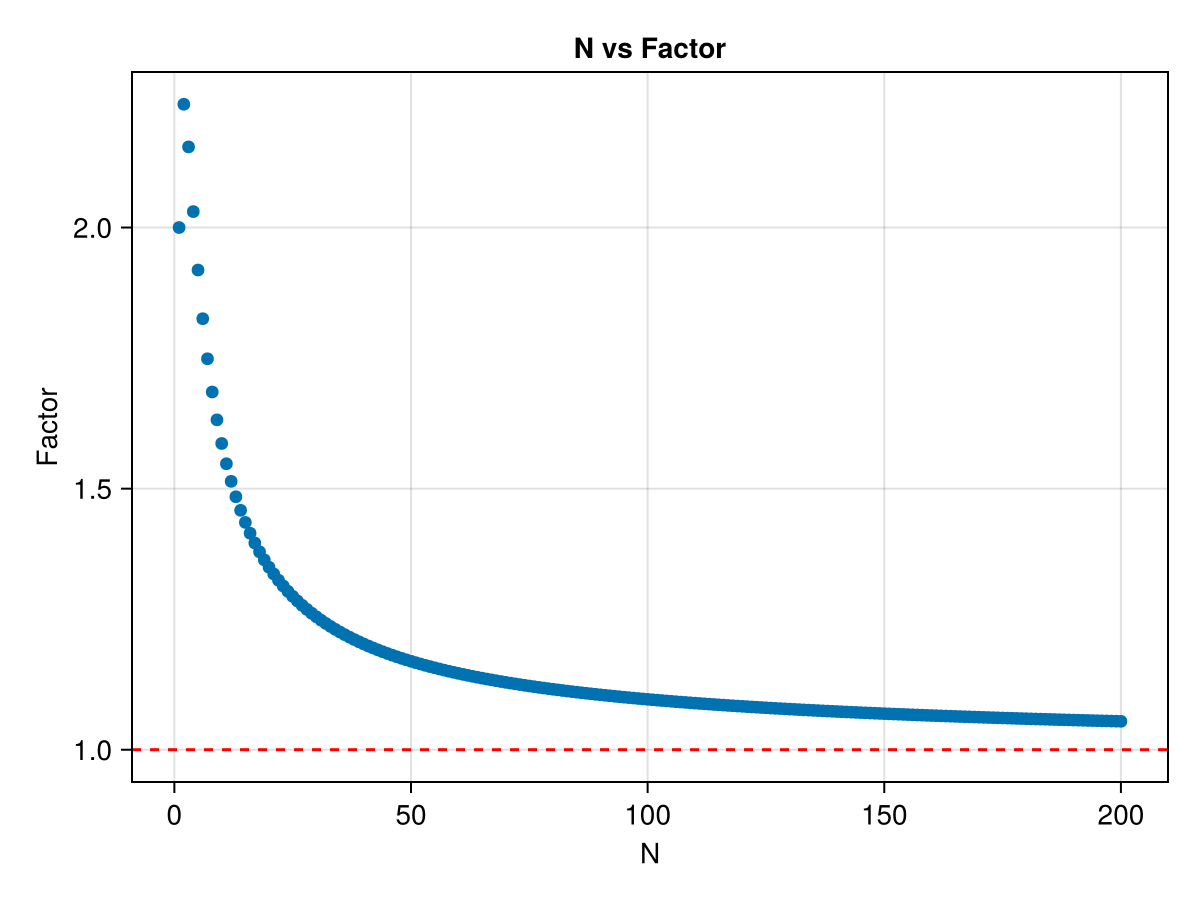

In [6]:
using CairoMakie

N_values=LinRange(1,200,200)

factors=zeros(Float64, 200)

for (i, n) in enumerate(N_values)
    factors[i] = (1+n*n)^(1/n)
end


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Factor", title="N vs Factor")
scatter!(ax, N_values, factors)
hlines!(ax, 1, color=:red, linestyle=:dash, label="1")
fig

Trial for eigenvalue expression

In [7]:
N=100
r= 1e-4
eta=1+1/N


1.01

In [8]:
eigen=[]
det_analytical=1.0
for i in 1:N
    eigenvalue =(2)^(1/(N-1))*(eta-1)*(2(i-1) + r) #(1+((eta-1)/N))*2^(2*(i-1)/((N-1)*(N-2)))*(eta-1)*(2(i-1) + r)            #

    if i==N
       eigenvalue =(1/2)*(1+N/(eta-1))*(eta-1)*(2(i-1) + r) #(N/2)*(1/(eta-1))*(eta-1)*(2(i-1) + r)             #
    end

    det_analytical*=eigenvalue
    push!(eigen, abs(eigenvalue))
end
display(det_analytical)
display(eigen[N])
display(eigen)

5.91737479020999e-15

9900.9950005

100-element Vector{Any}:
    1.0070260543835e-6
    0.020141528113724383
    0.040282049201394374
    0.06042257028906437
    0.08056309137673437
    0.10070361246440437
    0.12084413355207436
    0.14098465463974436
    0.16112517572741436
    0.18126569681508437
    0.20140621790275437
    0.22154673899042435
    0.24168726007809435
    ⋮
    1.7723668627410143
    1.7925073838286842
    1.8126479049163542
    1.8327884260040241
    1.8529289470916943
    1.8730694681793643
    1.8932099892670342
    1.9133505103547042
    1.933491031442374
    1.9536315525300443
    1.9737720736177142
 9900.9950005

In [76]:
M = zeros(Float64, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2(i-1) + r) *sqrt(2(j-1) + r)
            if i == j
                M[i, j] = (eta) * coeff
            else
                M[i, j] =coeff
            end
        end
    end

eigenvalues_real = eigvals(Matrix(M))    

determinant_real = (det(Matrix(M)))

5.917374790209553e-15

In [9]:
M = zeros(Float64, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2(i-1) + r) *sqrt(2(j-1) + r)
            if i == j
                M[i, j] = (1+1/N)* coeff
            else
                M[i, j] =coeff
            end
        end
    end

eigenvalues_real = eigvals(Matrix(M))    

determinant_real = (det(Matrix(M)))

LoadError: UndefVarError: `eigvals` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing LinearAlgebra in the current active module Main

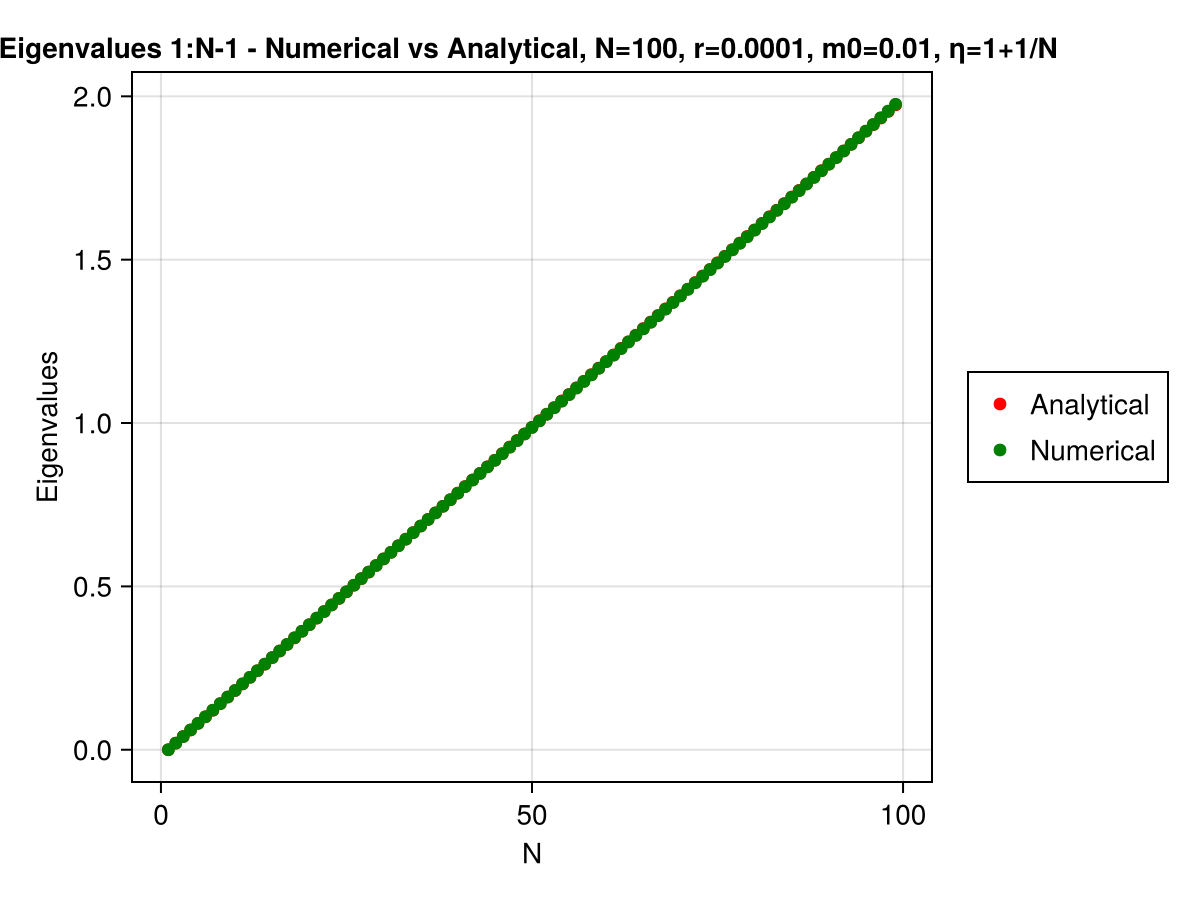

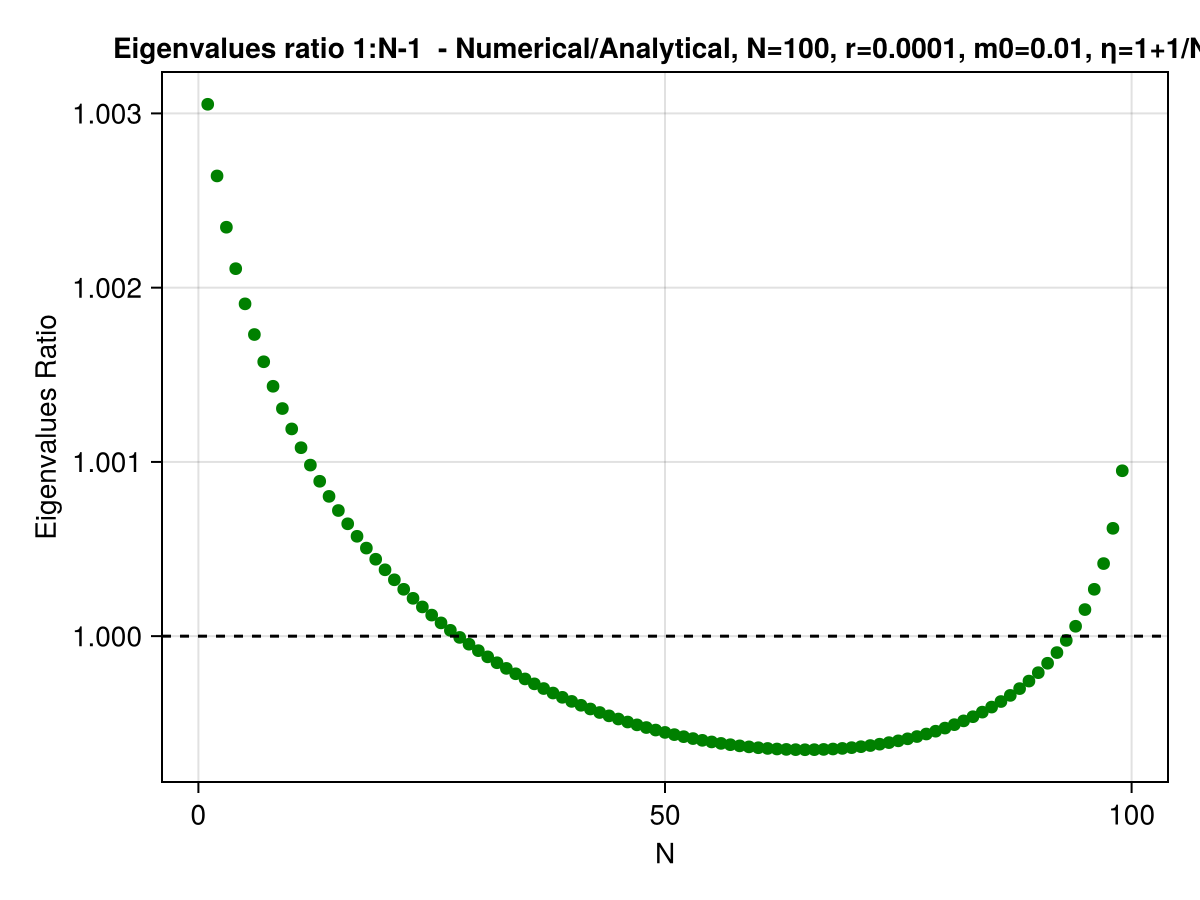

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie

N_values=LinRange(1,N,N)


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues", title="Eigenvalues 1:N-1 - Numerical vs Analytical, N=$N, r=$r, m0=0.01, η=1+1/N ")
scatter!(ax, N_values[1:N-1], eigen[1:N-1], color=:red, label="Analytical")
scatter!(ax, N_values[1:N-1], eigenvalues_real[1:N-1], color=:green, label="Numerical")

Legend(fig[1, 2], ax)
#save("/home/sofialon/Newtrinos.jl/plots_fix/eigenvalues_comp_N$(N)_r=$(r).png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues Ratio", title="Eigenvalues ratio 1:N-1  - Numerical/Analytical, N=$N, r=$r, m0=0.01, η=1+1/N ")
scatter!(ax, N_values[1:N-1], (eigenvalues_real[1:N-1])./eigen[1:N-1], color=:green, label="Numerical/Analytical")
hlines!(ax, 1, color=:black, linestyle=:dash, label="1")
#save("/home/sofialon/Newtrinos.jl/plots_fix/eigenvalues_res_N$(N)_r=$(r).png", fig1)
 display(fig1)

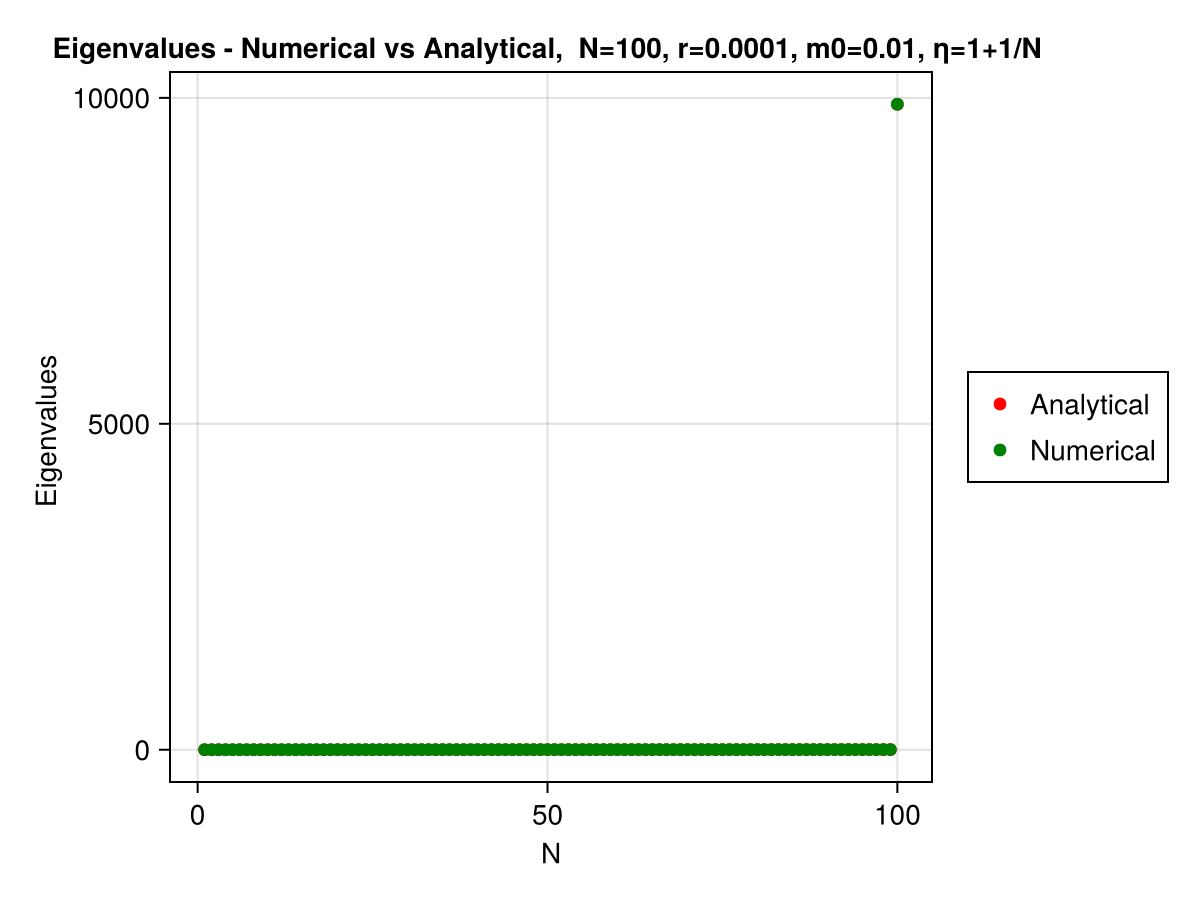

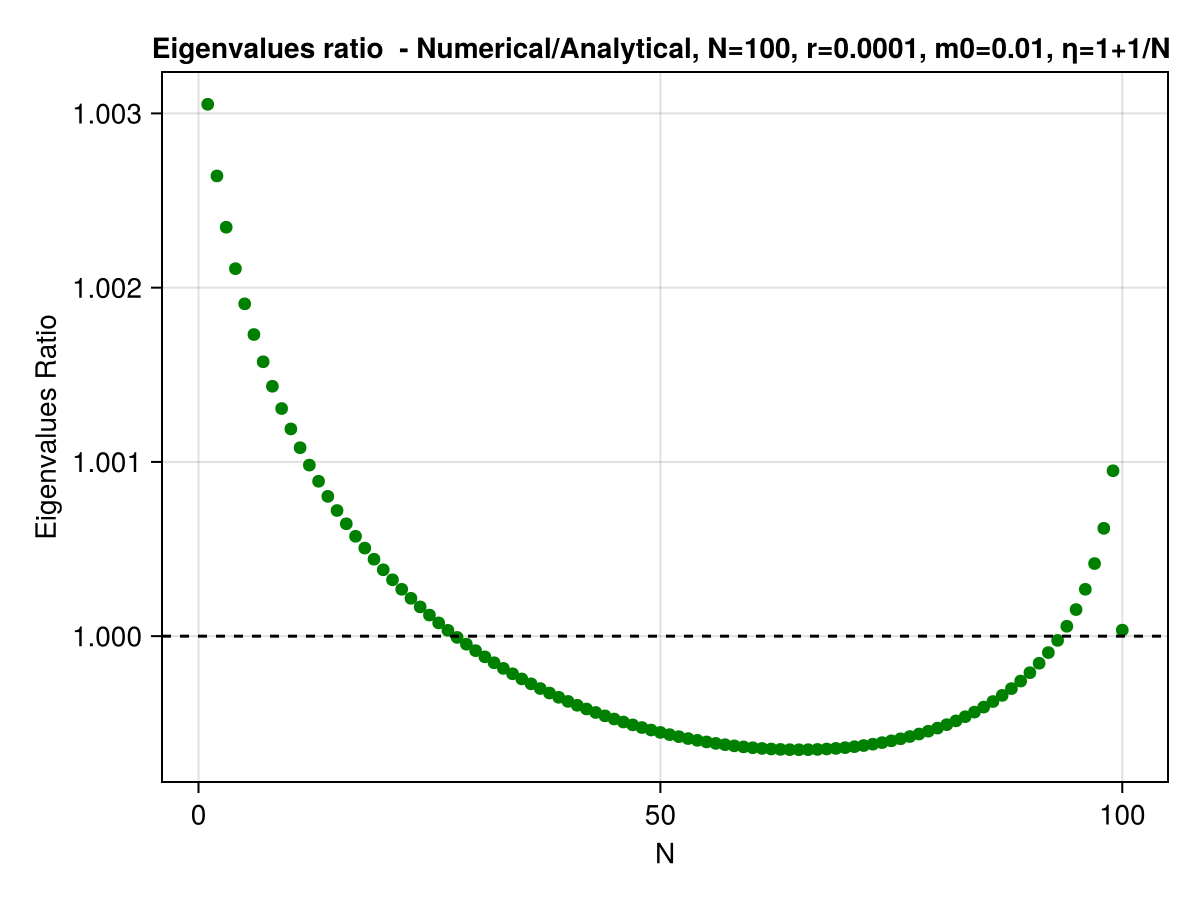

CairoMakie.Screen{IMAGE}


In [78]:


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues ", title="Eigenvalues - Numerical vs Analytical,  N=$N, r=$r, m0=0.01, η=1+1/N ")
scatter!(ax, N_values, eigen, color=:red, label="Analytical")
scatter!(ax, N_values, eigenvalues_real, color=:green, label="Numerical")

Legend(fig[1, 2], ax)
save("/home/sofialon/Newtrinos.jl/plots_fix/eigenvalues-1_comp_N$(N)_r=$(r).png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues Ratio", title="Eigenvalues ratio  - Numerical/Analytical, N=$N, r=$r, m0=0.01, η=1+1/N ")
scatter!(ax, N_values, (eigenvalues_real)./eigen, color=:green, label="Numerical/Analytical")
hlines!(ax, 1, color=:black, linestyle=:dash, label="1")
save("/home/sofialon/Newtrinos.jl/plots_fix/eigenvalues-1_res_N$(N)_r$(r).png", fig1)
display(fig1)

Comparison eigenvalues perturbation-full


In [13]:
using DataFrames
using Revise
using Newtrinos
using Newtrinos.osc

In [14]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 20.0, r = 1.0e-8, η = 1.05), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.05), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=40), r = Uniform{Float64}(a=1.0e-8, b=1.0), η = Uniform{Float64}(a=1.000000001, b=1.1)), Newtrinos.osc.var"#get_Nnaturalness#55"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{Oscillati

In [16]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [17]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [18]:
par = Newtrinos.get_params(experiments)
p=merge(par, (r=0.5,))

(N = 20.0, m₀ = 0.01, r = 0.5, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [19]:
N=p.N
m0=p.m₀
r=p.r


0.5

In [74]:
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
FinalUmatrix, h, eigenvalues = f1(p)

file_name_eigen="/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_pertnew_NNM_NO_$N $r $m0.txt"

open(file_name_eigen, "w") do io
    for i in 1:length(eigenvalues)
        @printf(io, "%f\n", eigenvalues[i])
    end
end 

file_name_h="/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_pertnew_NNM_NO_$N $r $m0.txt"

open(file_name_h, "w") do io
    for i in 1:length(h)
        @printf(io, "%f\n", h[i])
    end
end 


In [20]:
#analytical eigenvalues new
m1,m2,m3=Newtrinos.osc.get_abs_masses(p)

eigen_analytical=[]


N=par.N
η=1+(1/N)#params[:η]#1+N_dual#1+(1/N_dual)
#factor=2^(2*(i-1)/(N-1)(N-2))
factorN= (0.5*N/(η-1))^2#(0.5*(1+(N/(η-1))))^2


for i in 1:N
    eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2 )*(2^(2*(i-1)/((N-1)*(N-2))))^2*(1+((η-1)/N))^2
    eigenvalue_mu=((2(i-1) + r)^2*m2^2/r^2)*(2^(2*(i-1)/((N-1)*(N-2))))^2*(1+((η-1)/N))^2
    eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)*(2^(2*(i-1)/((N-1)*(N-2))))^2*(1+((η-1)/N))^2

    if i==N
         eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2)*factorN
    
         eigenvalue_mu =((2(i-1) + r)^2*m2^2/r^2)*factorN
    
         eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)*factorN
    end

    push!(eigen_analytical, eigenvalue_e)
    push!(eigen_analytical, eigenvalue_mu)
    push!(eigen_analytical, eigenvalue_t)

end

#eigen_analytical=sort(eigen_analytical)    
#eigen_analytical[1]=m1^2
#eigen_analytical[2]=m2^2
#eigen_analytical[3]=m3^2

#eigen_analytical[end-2]=eigen_analytical[end-2]*factor^2/factorN^2
#eigen_analytical[end-1]=eigen_analytical[end-1]*factor^2/factorN^2
#eigen_analytical[end]=eigen_analytical[end]*factor^2/factorN^2

In [ ]:
#analytical eigenvalues first
m1,m2,m3=Newtrinos.osc.get_abs_masses(p)

eigen_analytical=[]


N=par.N
η=1+(1/N)
factor=((η-1) * 2^(1/(N-1)))^2
factorN= (0.5*(η-1)*(1+(N/(η-1))))^2


for i in 1:N
    eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2)
    eigenvalue_mu=((2(i-1) + r)^2*m2^2/r^2)
    eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)

    if i==N
         eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2)*factorN/factor
    
         eigenvalue_mu =((2(i-1) + r)^2*m2^2/r^2)*factorN/factor
    
         eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)*factorN/factor
    end

    push!(eigen_analytical, eigenvalue_e)
    push!(eigen_analytical, eigenvalue_mu)
    push!(eigen_analytical, eigenvalue_t)

end

#eigen_analytical=sort(eigen_analytical)    
#eigen_analytical[1]=m1^2
#eigen_analytical[2]=m2^2
#eigen_analytical[3]=m3^2

#eigen_analytical[end-2]=eigen_analytical[end-2]*factor^2/factorN^2
#eigen_analytical[end-1]=eigen_analytical[end-1]*factor^2/factorN^2
#eigen_analytical[end]=eigen_analytical[end]*factor^2/factorN^2

0.002575299999999999

In [86]:
#analytical h


h_analytical=[]

for i in 1:60
    h=eigen_analytical[i] -eigen_analytical[1]
    push!(h_analytical, h)
end
h_analytical=sort(h_analytical)    
#h_analytical[1]=0
#h_analytical[2]=p.Δm²₂₁
#h_analytical[3]=p.Δm²₃₁


60-element Vector{Any}:
      0.0
      7.53e-5
      0.0024000000000000002
      0.0024752999999999993
      0.0042825
      0.008
      0.0140993
      0.016800000000000002
      0.028800000000000003
      0.029525700000000002
      0.044
      0.0505617
      0.0624
      ⋮
      4.3289792999999985
      5.214882499999998
      6.183195299999998
      7.2339176999999975
      8.367049699999997
      9.582591299999997
     10.880542499999997
     12.260903299999995
     13.723673699999996
  22157.60593497672
  38842.28327931419
 570624.8281187554

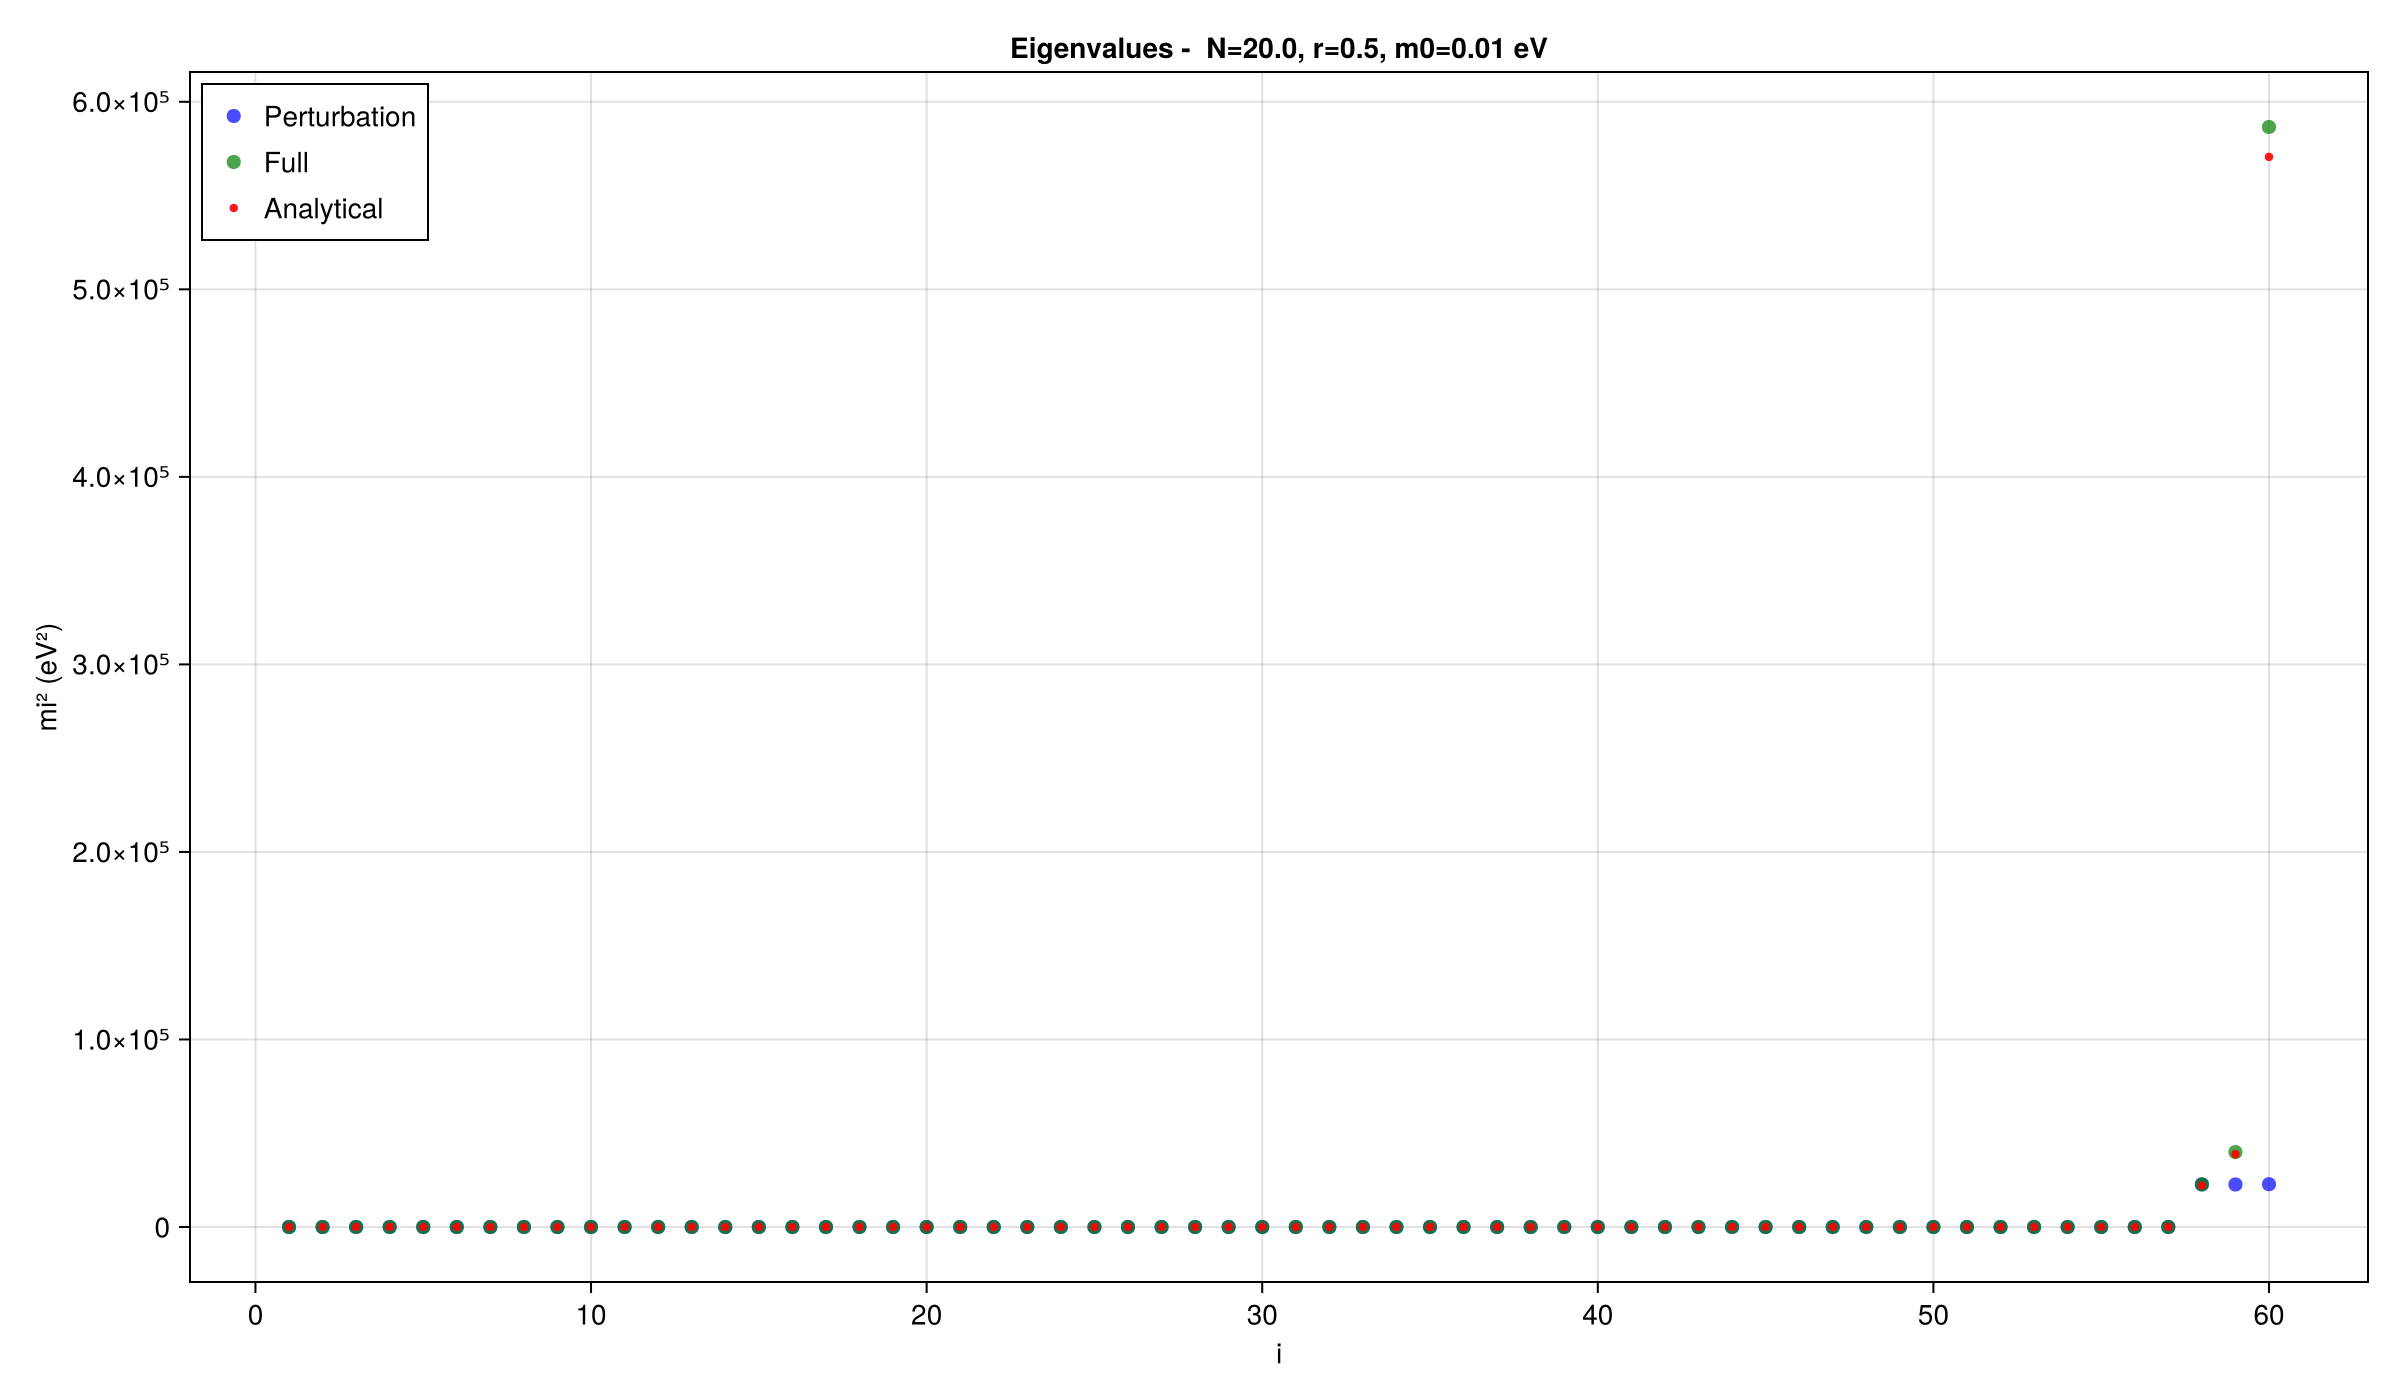

In [87]:
using CairoMakie
using DelimitedFiles

# Read the three txt files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_fullold_NNM_NO_$N $r $m0.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_pertnew_NNM_NO_$N $r $m0.txt"))


file1=(sort(file1[1:end]))
file2=(sort(file2[1:end]))

# Create indices for x-axis
indices1 = 1:length(file1)
indices2 = 1:length(file2)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="mi² (eV²)",
    title="Eigenvalues -  N=$N, r=$r, m0=$m0 eV")

# Plot scatter points for each file with different colors

scatter!(ax, indices1, file2, label="Perturbation", markersize=10, alpha=0.7, color=:blue)

scatter!(ax, indices2, file1, label="Full", markersize=10, alpha=0.7, color=:green)

scatter!(ax, indices2, sort(eigen_analytical[1:end]), label="Analytical", markersize=6, alpha=0.9, color=:red)
#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/oldeigenvalues_all_comp_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


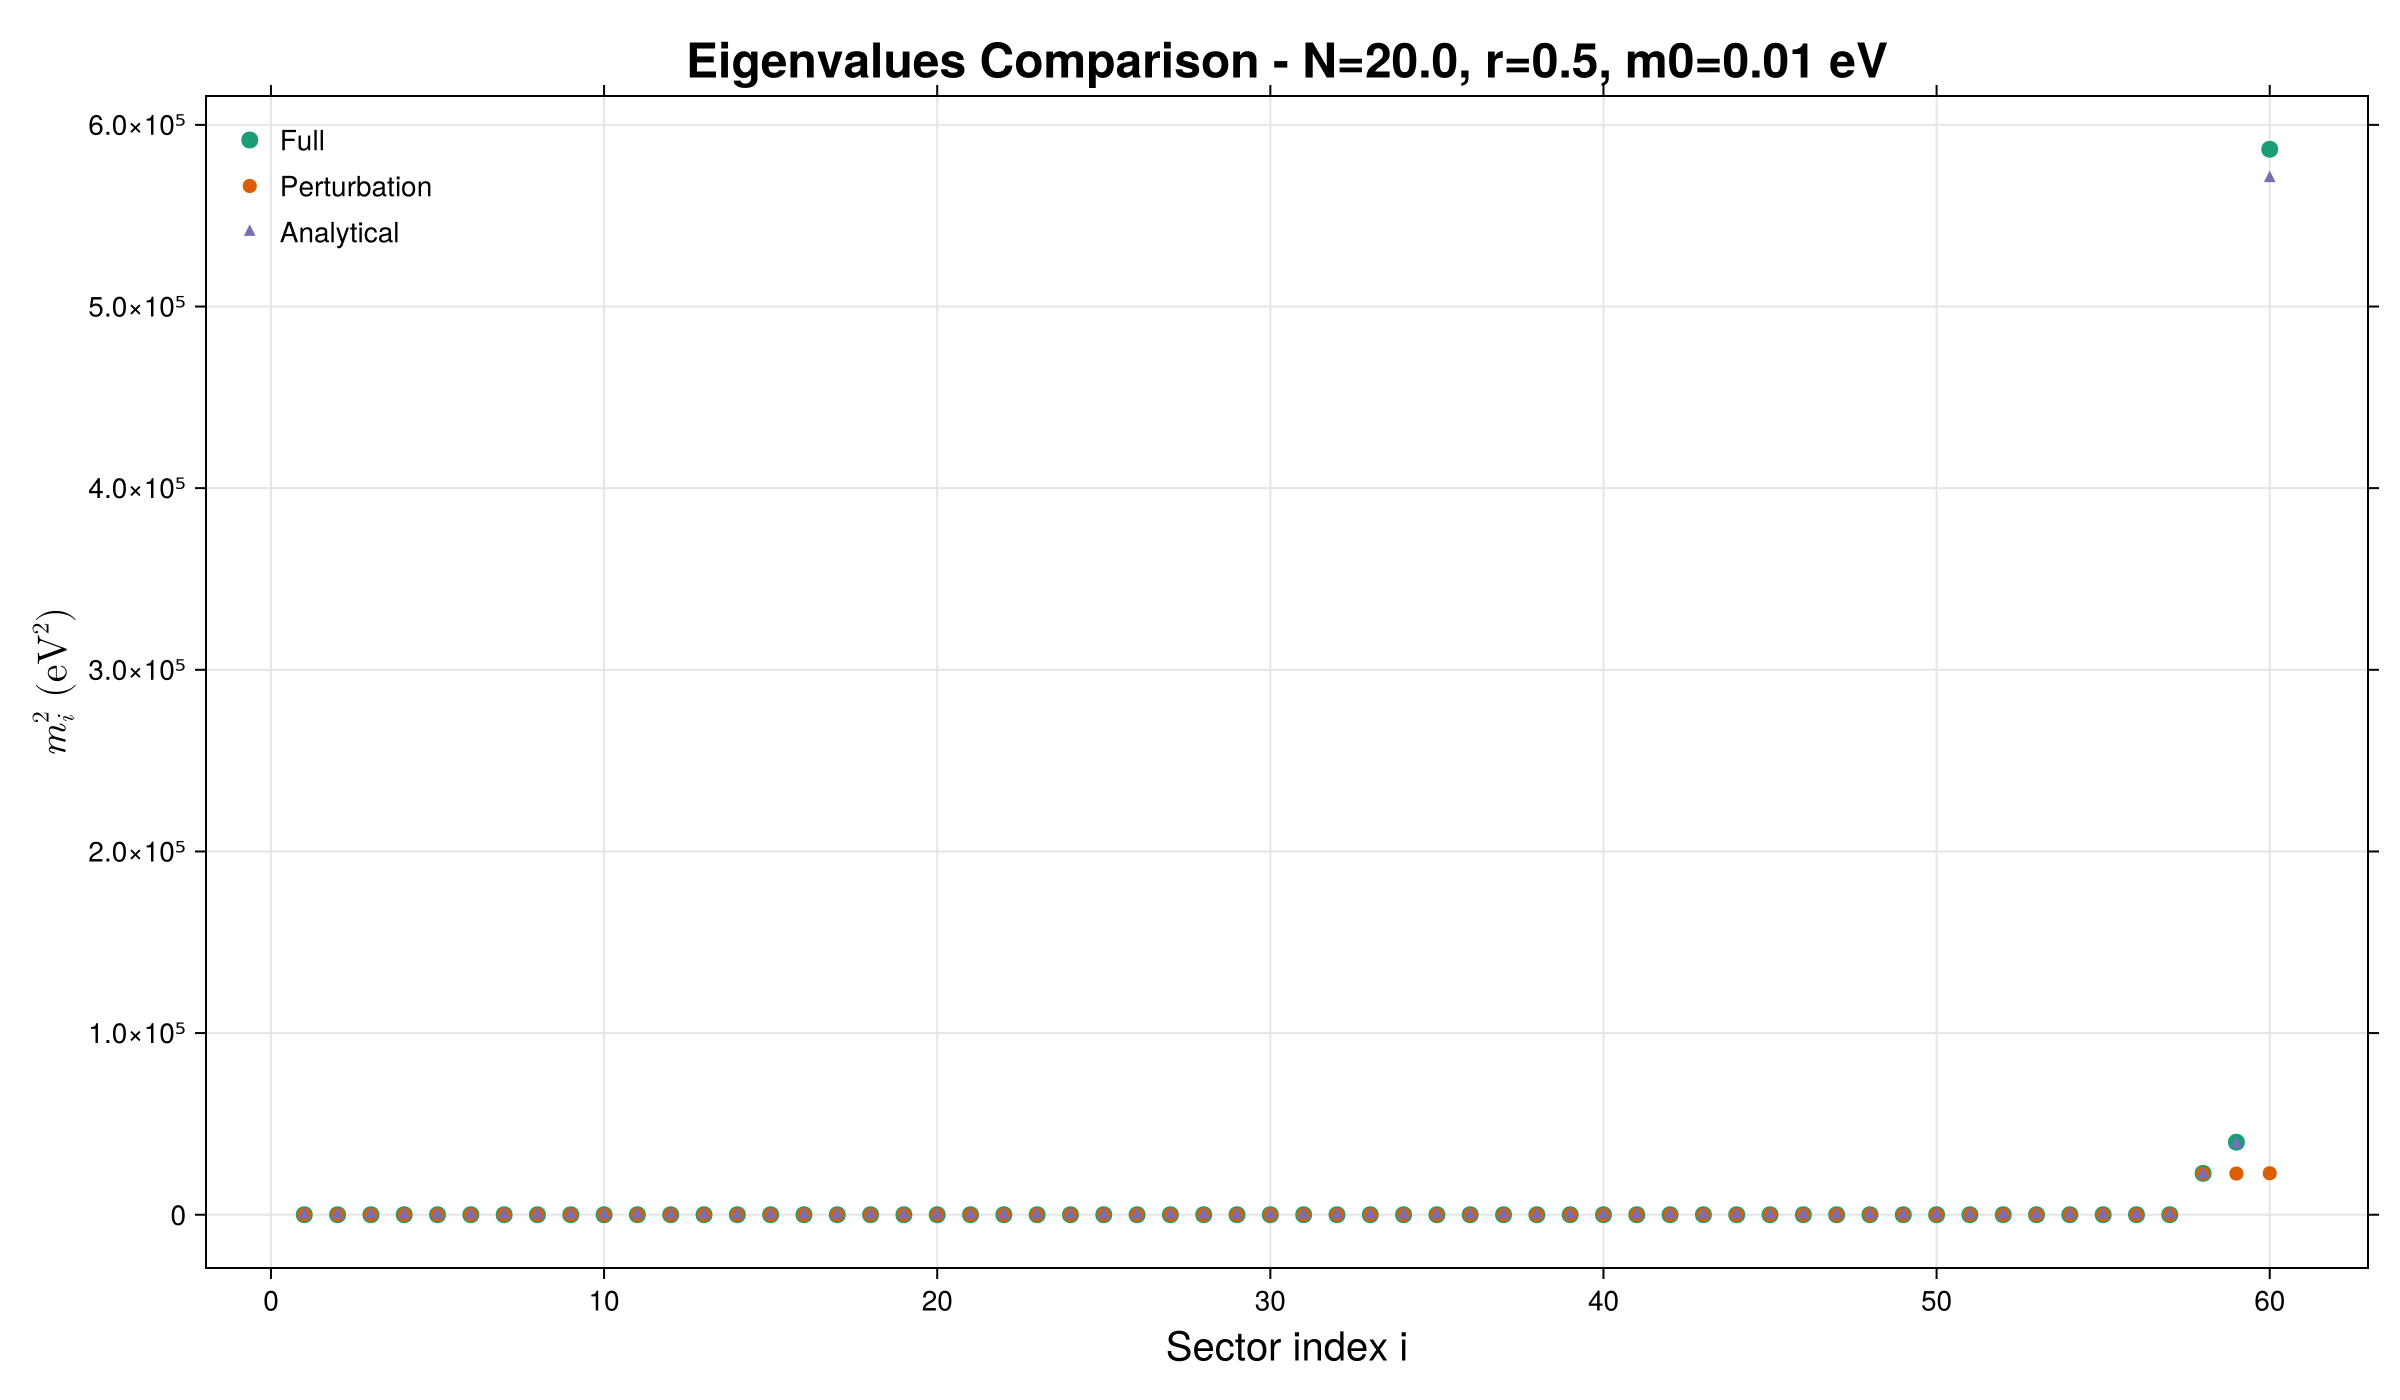

CairoMakie.Screen{IMAGE}


In [88]:
using CairoMakie
using DelimitedFiles
using Colors

# Read files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_fullold_NNM_NO_$N $r $m0.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_pertnew_NNM_NO_$N $r $m0.txt"))

file1 = sort(file1)
file2 = sort(file2)
analytical_sorted = sort(eigen_analytical)  # assuming this exists

indices = 1:length(file1)

# Colors
palette = cgrad(:Dark2_8, categorical=true)
color_full = palette[1]
color_perturb = palette[2]
color_analytical = palette[3]

# Construct title with interpolation first
title_latex = "Eigenvalues Comparison - N=$N, r=$r, m0=$m0 eV"

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)

ax = Axis(fig[1, 1],
    xlabel="Sector index i",
    ylabel=L"m_i^2~(\mathrm{eV}^2)",
    title=title_latex,
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Scatter plots
scatter!(ax, indices, file1, color=color_full, label="Full", markersize=12)
scatter!(ax, indices, file2, color=color_perturb, label="Perturbation", markersize=10)
scatter!(ax, indices, analytical_sorted, color=color_analytical, label="Analytical", markersize=8, marker=:utriangle)

# Legend
axislegend(ax, position=:lt, framevisible=false, fontsize=20)


save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_comparison_NNM_NO_$N $r $m0.png", fig)
display(fig)


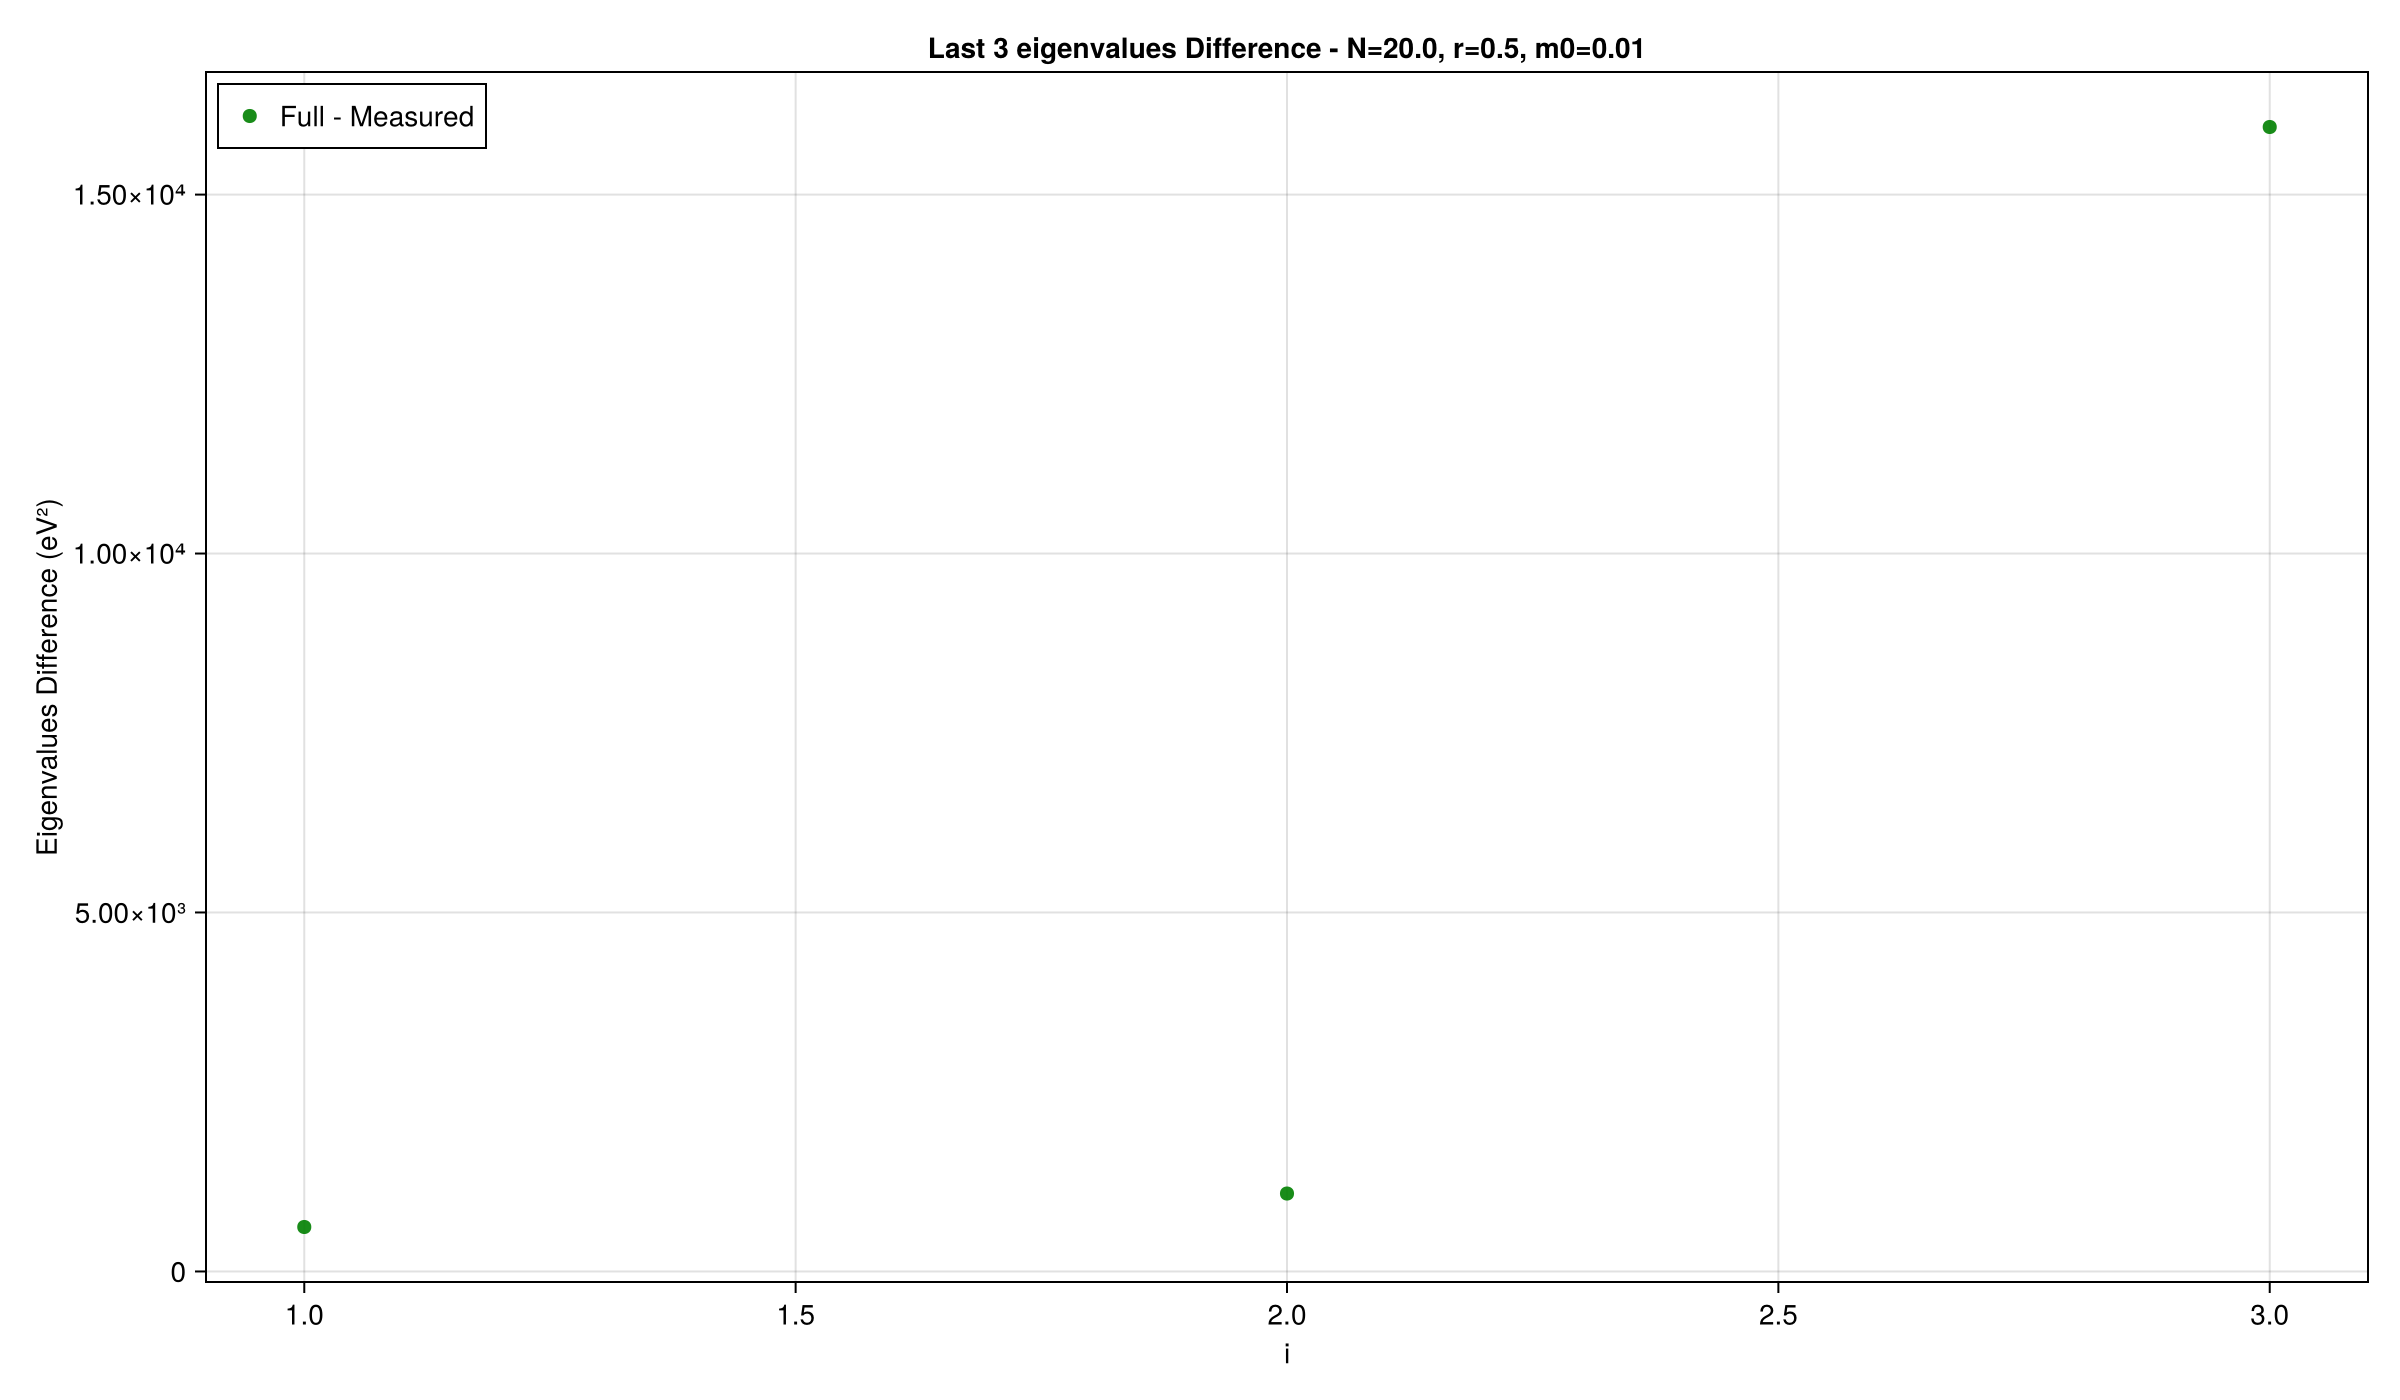

In [89]:


residues_1 = vec(((file1 .- file2) ))#./ file1) .* 100)
residues_2 = vec(((file1 .- eigen_analytical[1:end]) ))#./ file1) .* 100)
residues_3 = vec(((file2 .- eigen_analytical[1:end])) )#./ file2) .* 100)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Difference (eV²)",
    title="Last 3 eigenvalues Difference - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:3], residues_1[1:3], label="Perturbation - Full", markersize=15, alpha=0.5, color=:purple)
#scatter!(ax,  indices1[1:3], residues_3[end-2:end], label="Perturbation - Measured", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:3], residues_2[end-2:end], label="Full - Measured", markersize=10, alpha=0.9, color=:green)



#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_difflast3_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


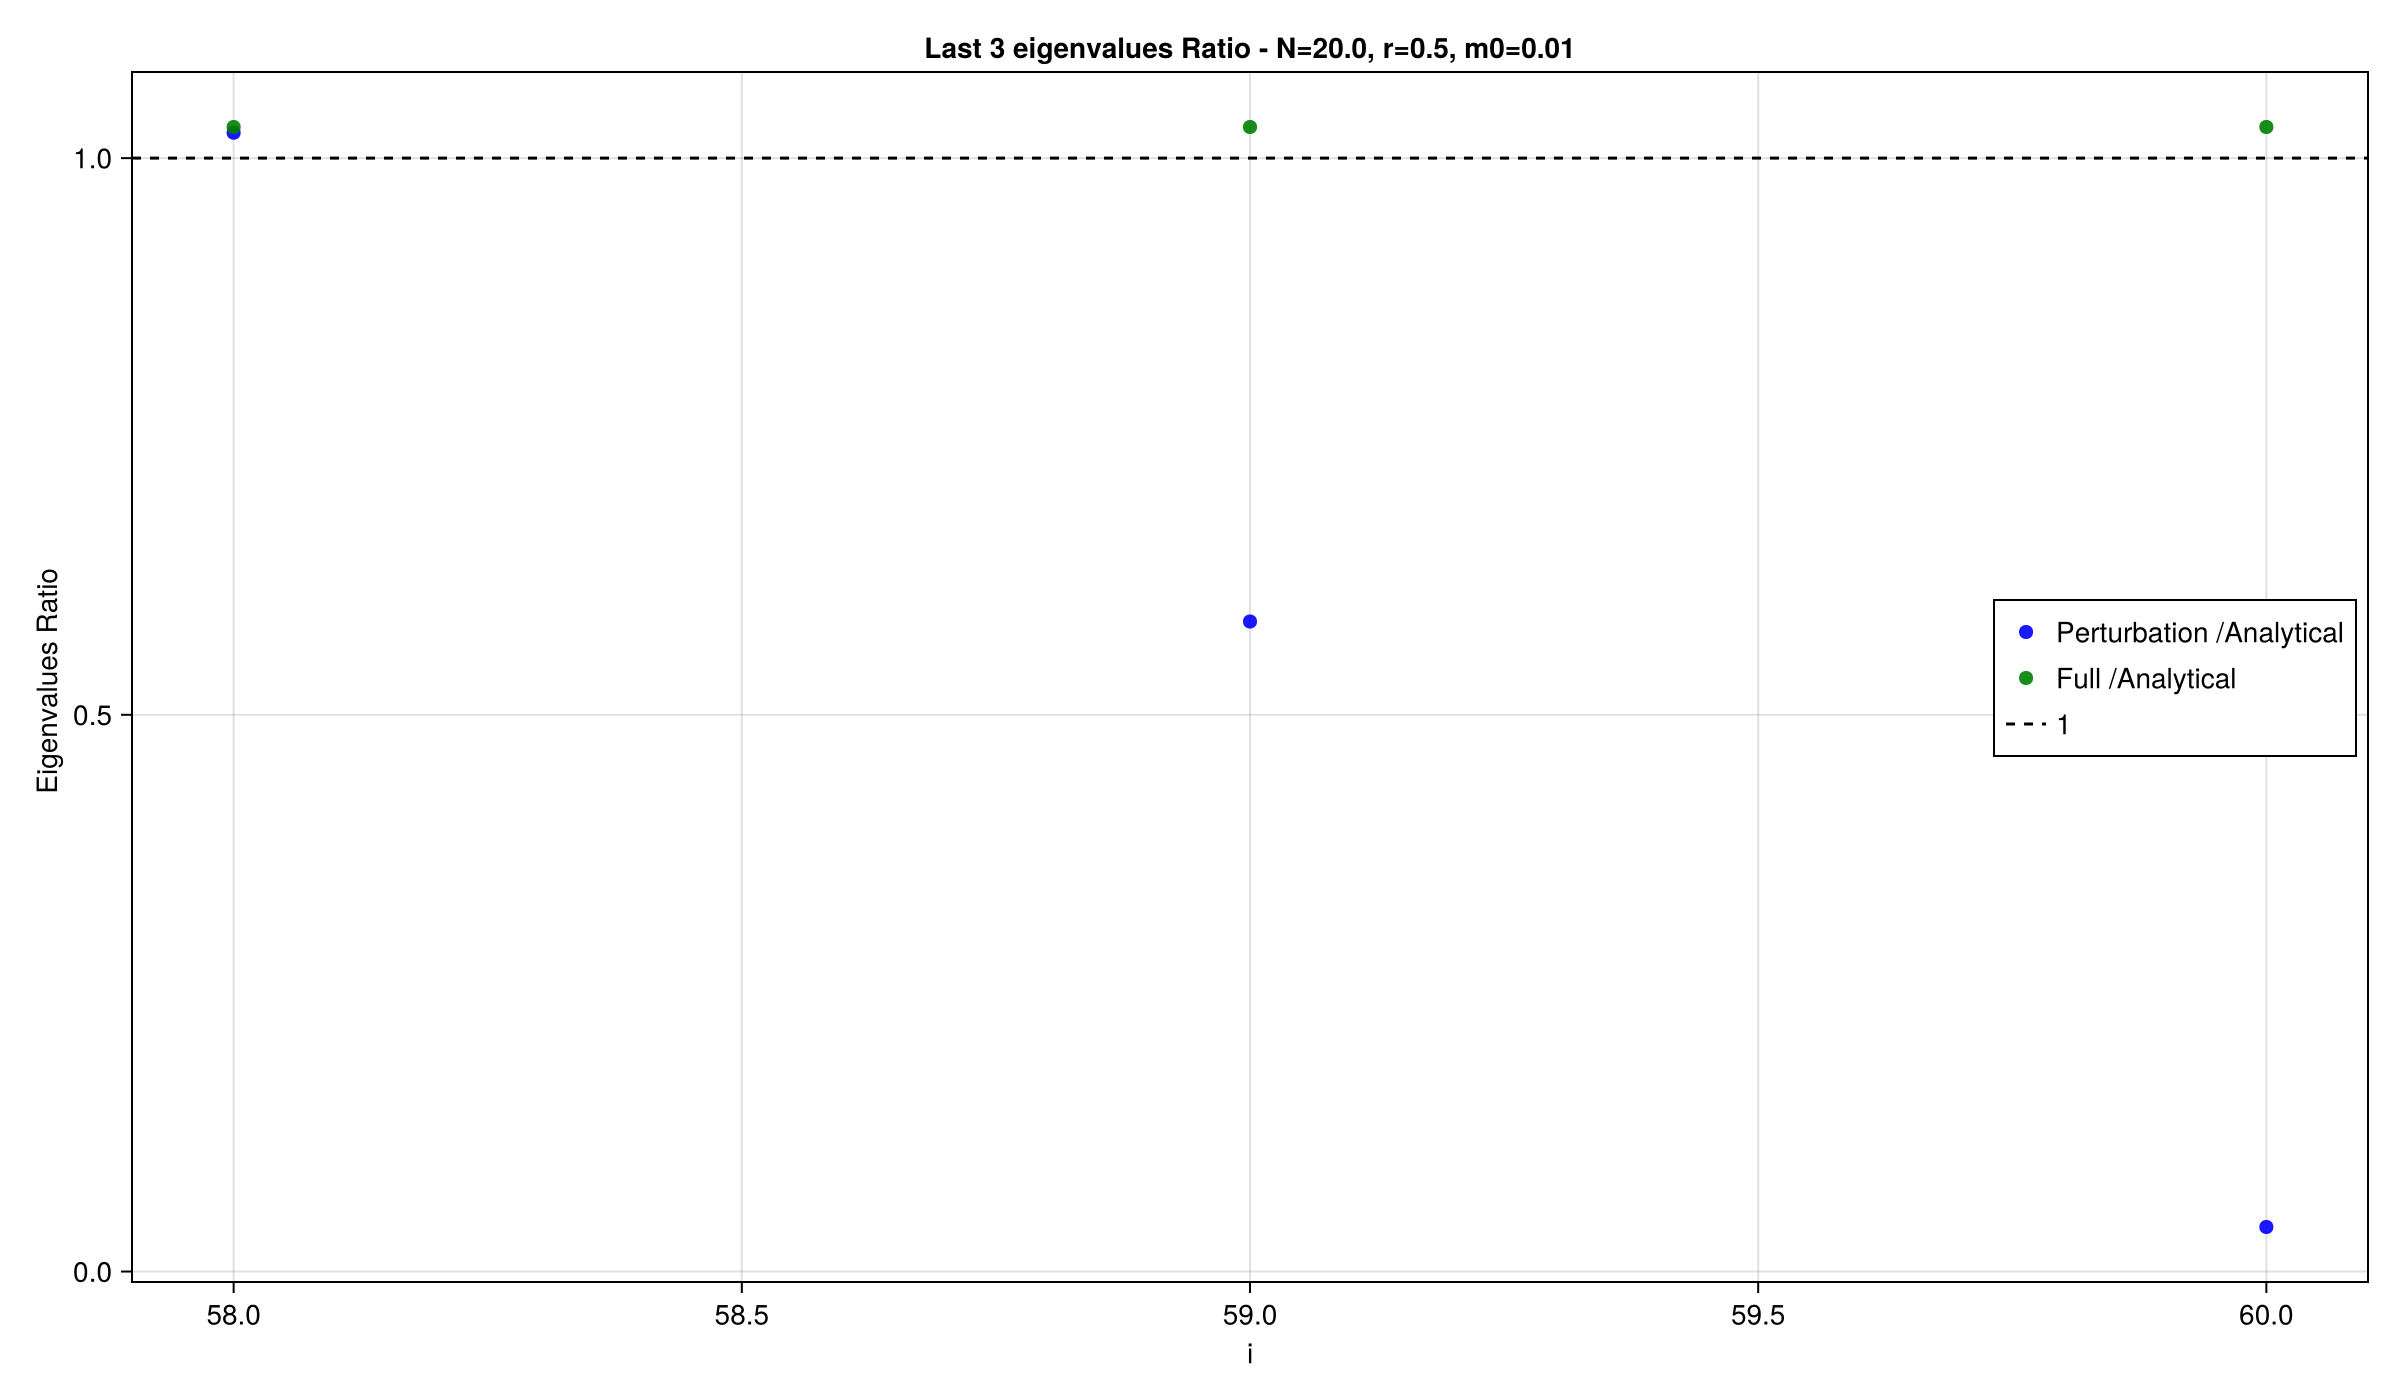

In [90]:


residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((file1 ./ eigen_analytical[1:end]) ))#./ file1) .* 100)
residues_3 = vec(((file2 ./ eigen_analytical[1:end])) )#./ file2) .* 100)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Ratio ",
    title="Last 3 eigenvalues Ratio - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:3], residues_1[1:3], label="Perturbation /Full", markersize=15, alpha=0.5, color=:purple)
scatter!(ax,  indices1[58:60], residues_3[end-2:end], label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[58:60], residues_2[end-2:end], label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash, label="1")

#ylims!(ax, 0,40)
# Add legend
axislegend(ax, position=:rc)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/oldeigenvalues_ratiolast3_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


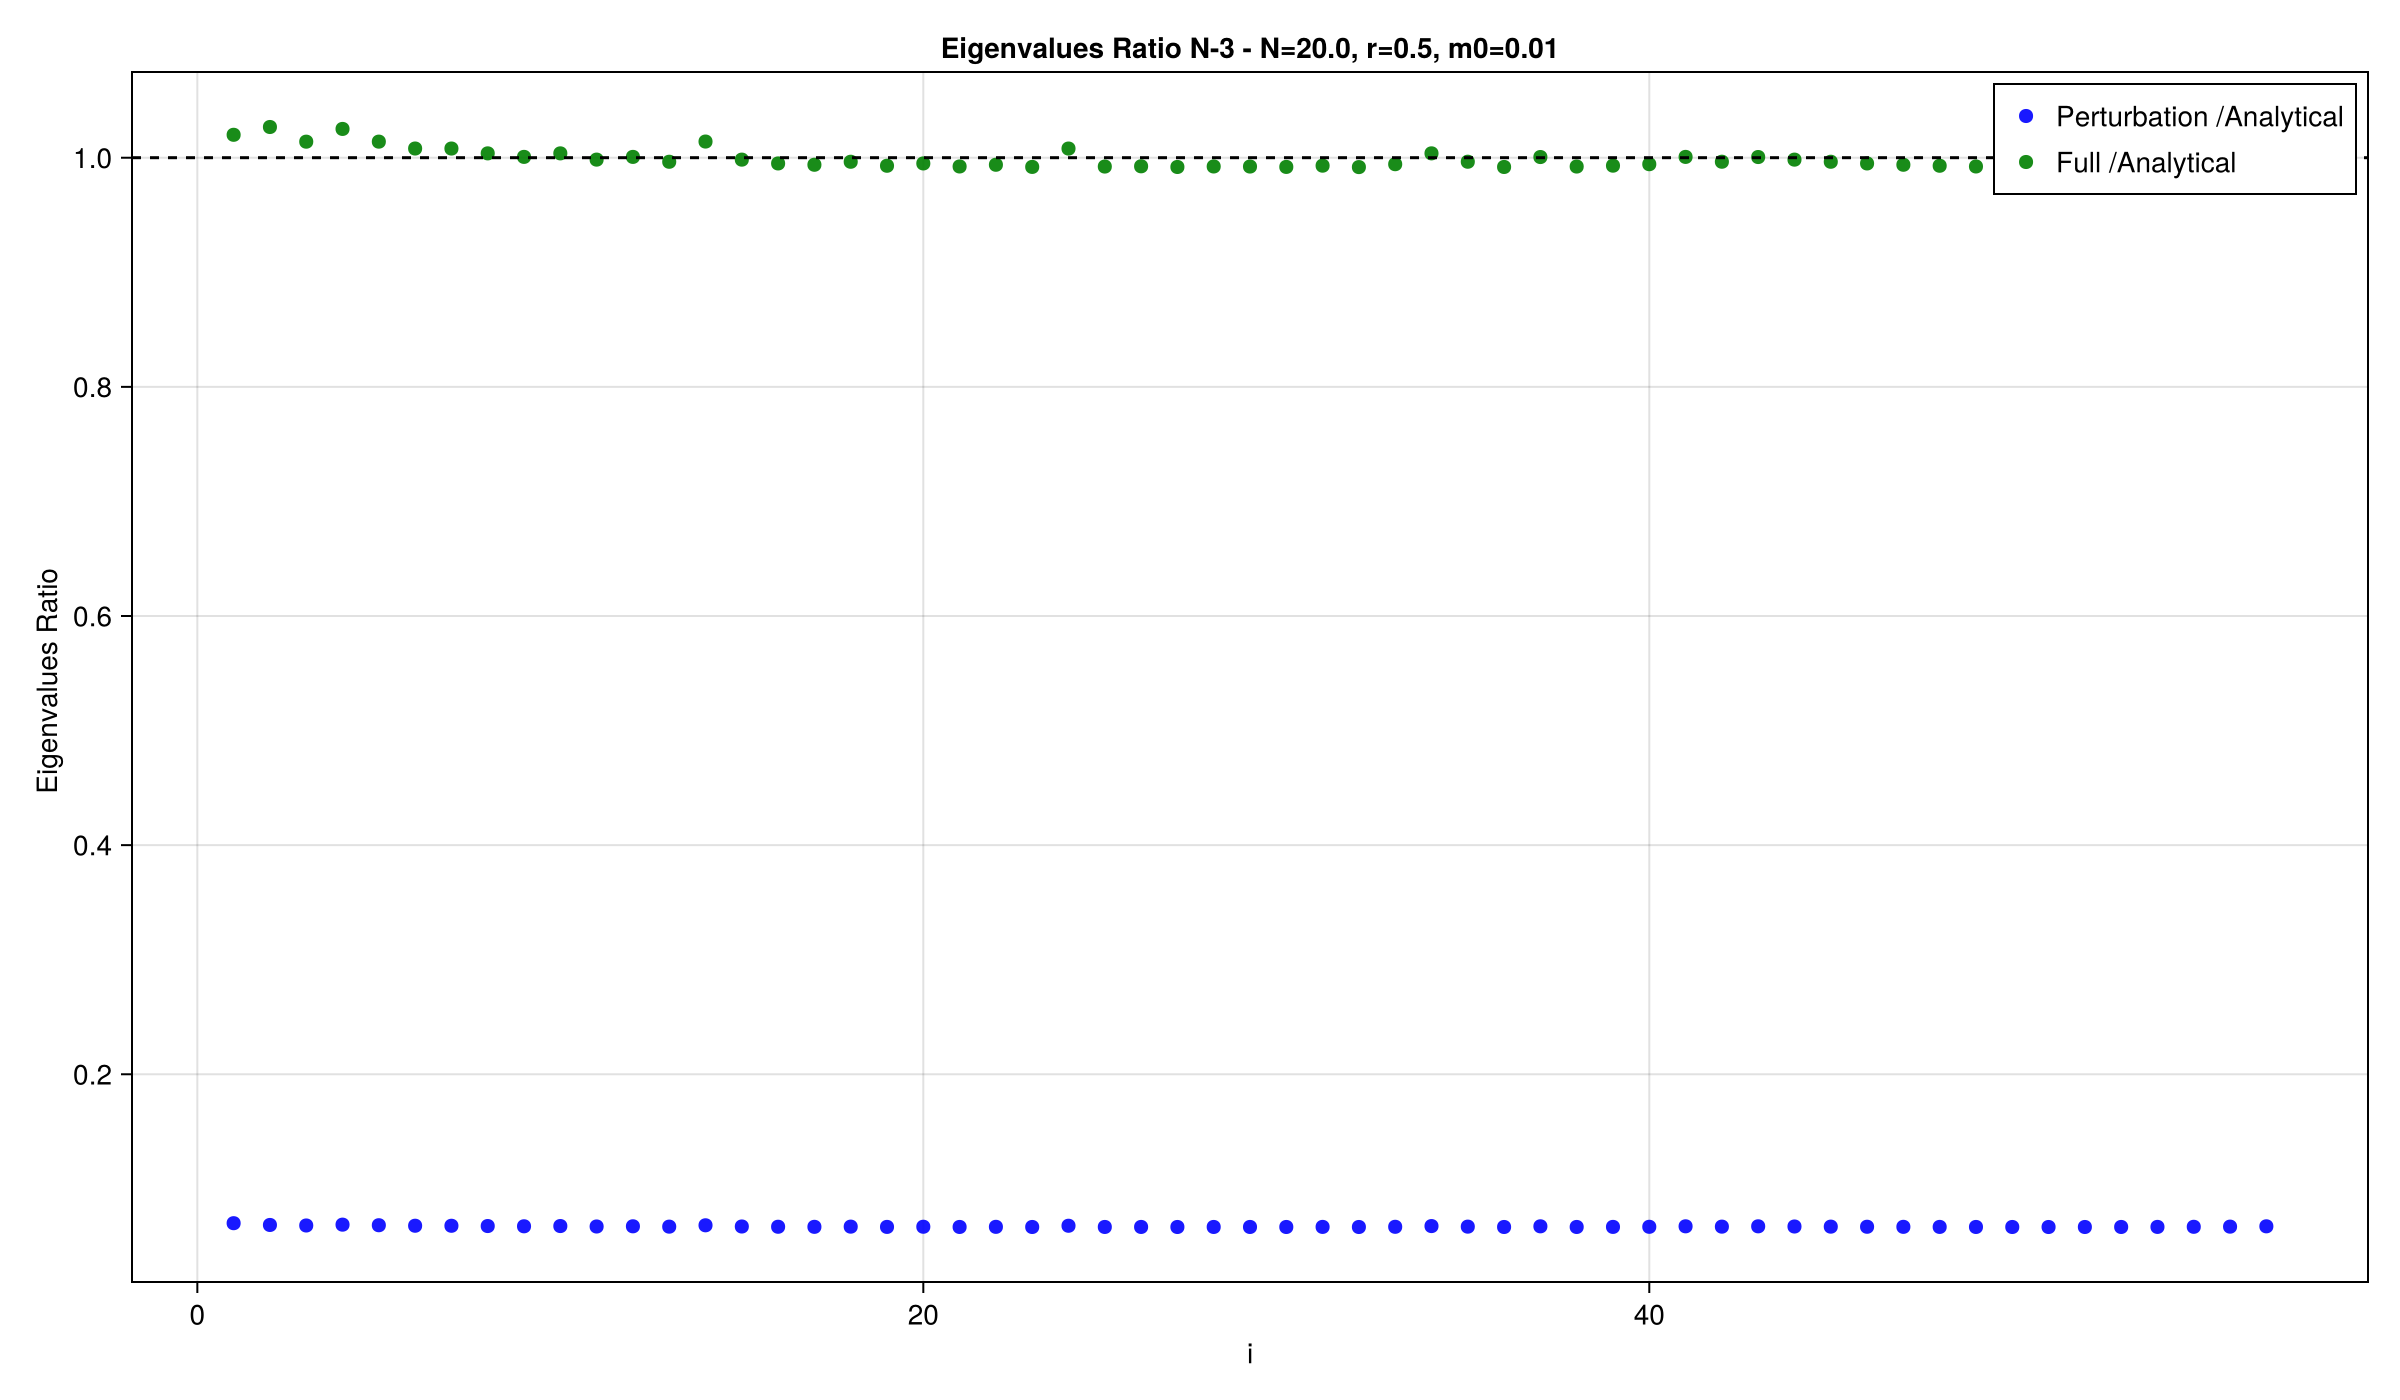

CairoMakie.Screen{IMAGE}


In [91]:



residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((sort(file1) ./ sort(eigen_analytical[1:end])) ))#./ file1) .* 100)
residues_3 = vec(((sort(file2) ./ sort(eigen_analytical[1:end])) ))#./ file2) .* 100)



# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Ratio ",
    title="Eigenvalues Ratio N-3 - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:end-3], residues_1[1:end-3], label="Perturbation /Full", markersize=10, alpha=0.9, color=:purple)
scatter!(ax,  indices1[1:end-3],(residues_3[1:end-3]), label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end-3], (residues_2[1:end-3]), label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash)

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:rt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_ratio_NNM_NO_$N $r $m0.png", fig)
display(fig)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


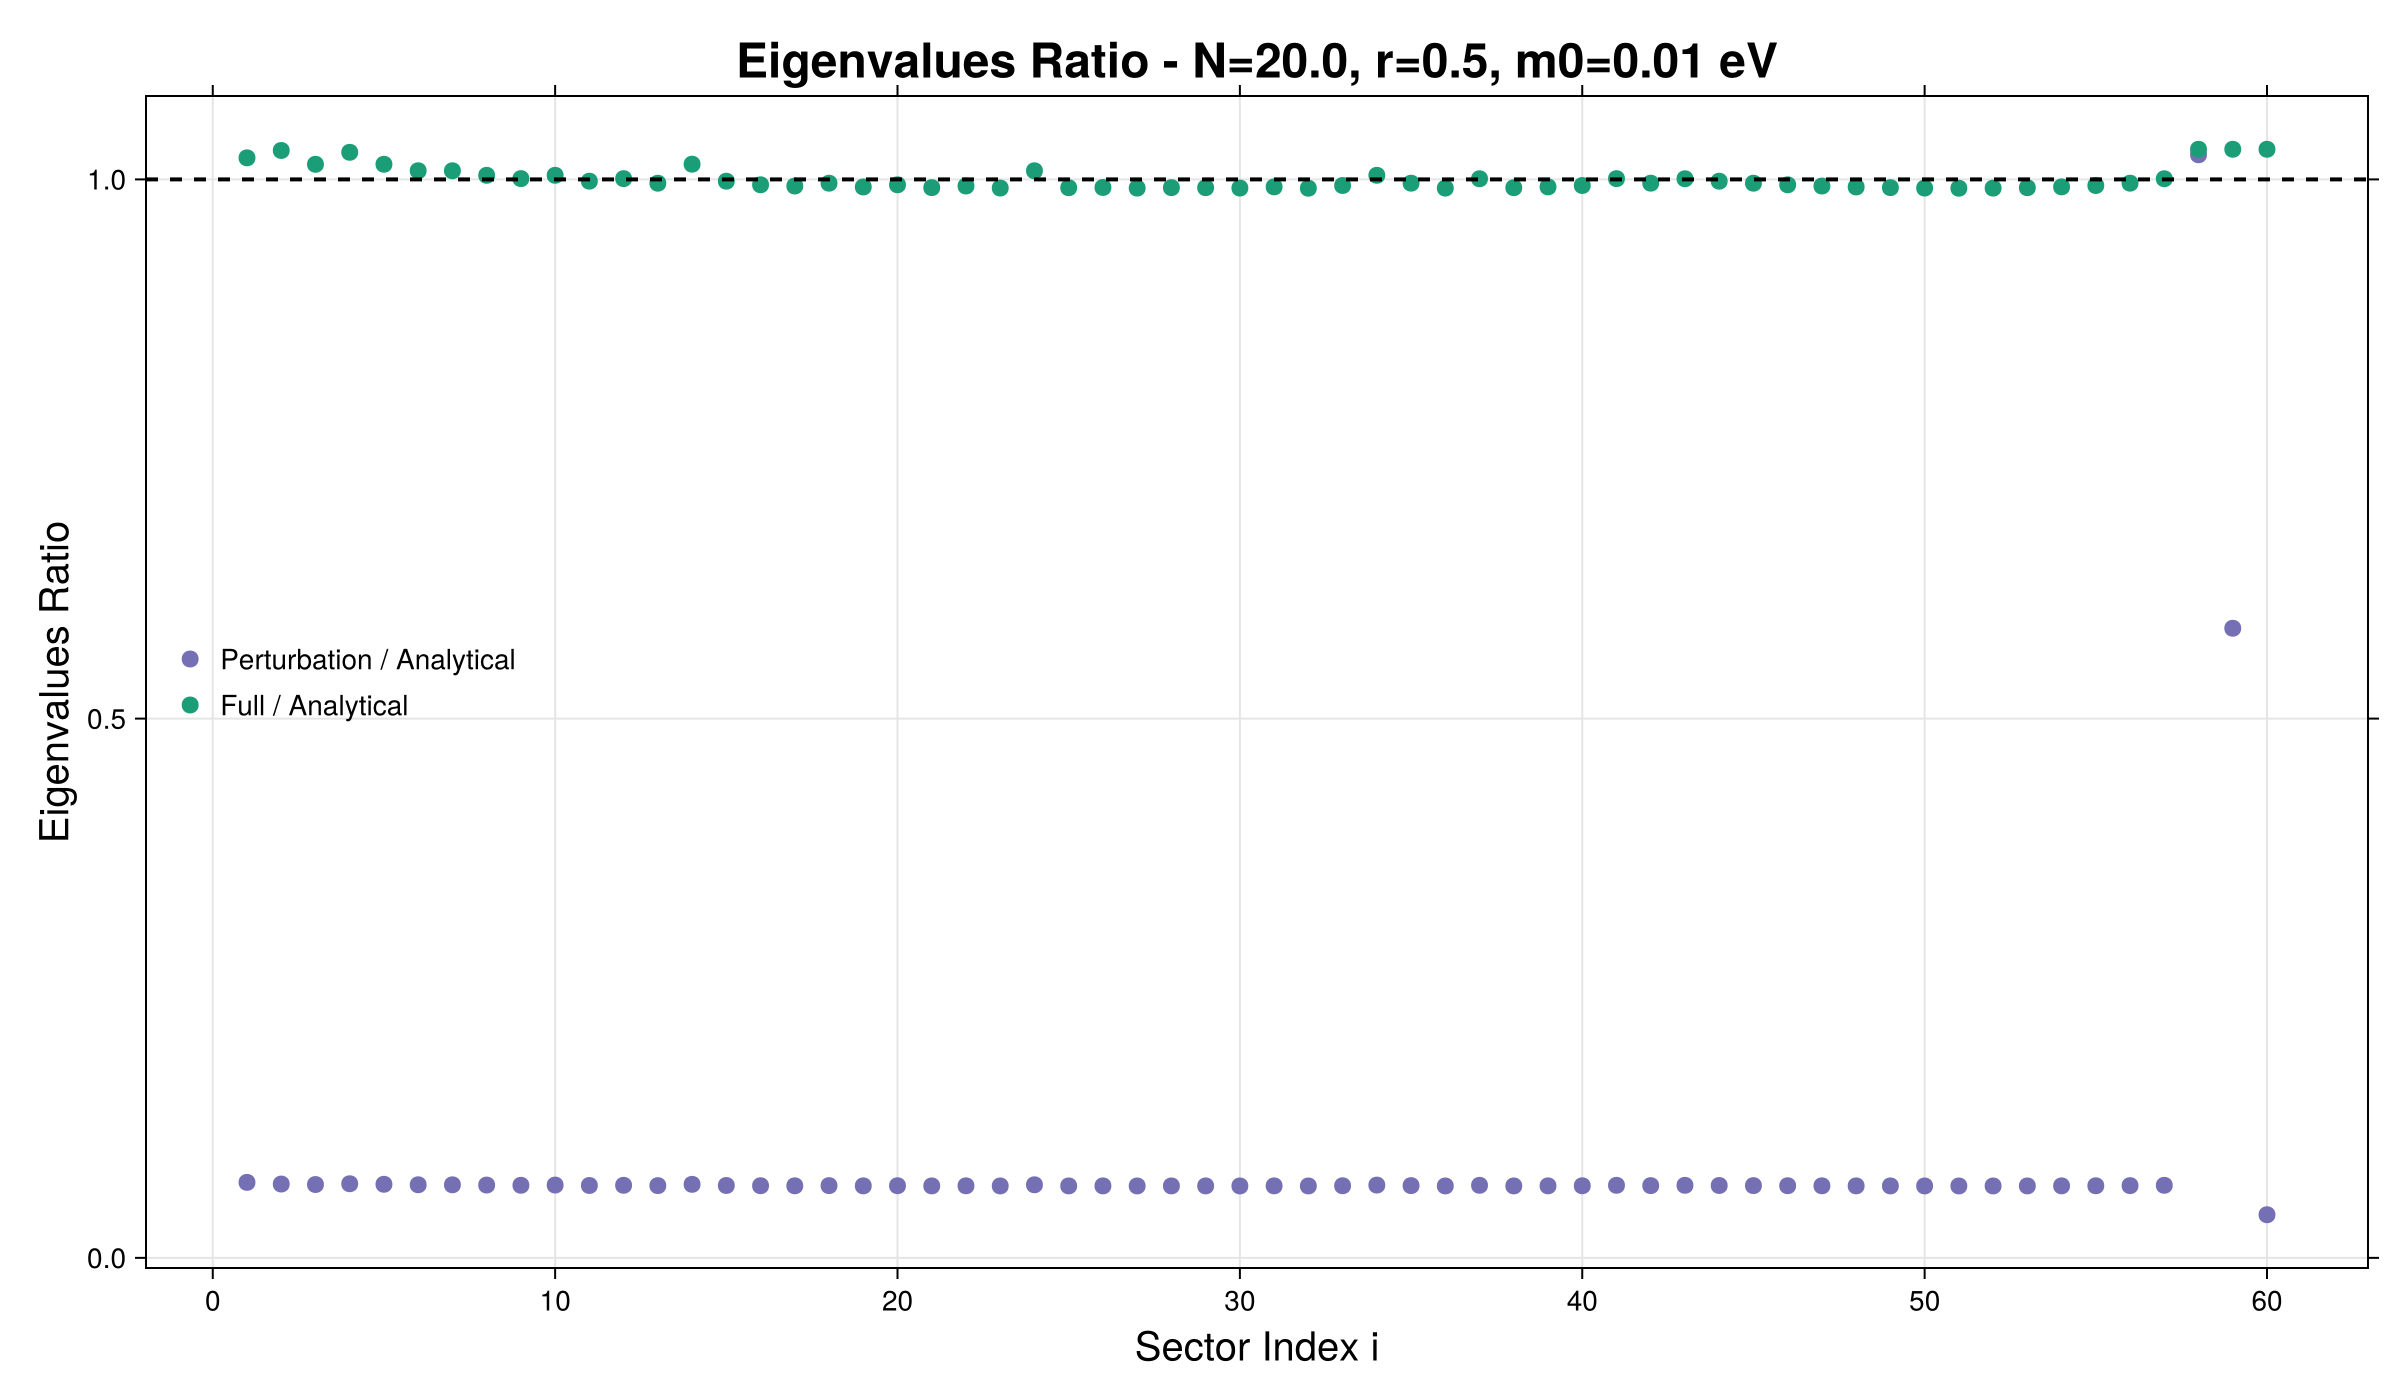

In [92]:
using CairoMakie
using Colors

residues_1 = file1 ./ file2
residues_2 = sort(file1) ./ sort(eigen_analytical)
residues_3 = sort(file2) ./ sort(eigen_analytical)


# Dark2_8 palette
palette = cgrad(:Dark2_8, categorical=true)
color_pert_analytical = palette[3]   # blue-ish
color_full_analytical = palette[1]   # green-ish
       # purple-ish (optional)

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)

title_str = "Eigenvalues Ratio - N=$N, r=$r, m0=$m0 eV"
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Eigenvalues Ratio",
    title=title_str,   # plain string
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)


# Plot scatter points
scatter!(ax, indices1[1:end], residues_3[1:end],
    label="Perturbation / Analytical",
    color=color_pert_analytical,
    markersize=12
)

scatter!(ax, indices2[1:end], residues_2[1:end],
    label="Full / Analytical",
    color=color_full_analytical,
    markersize=12
)

# Horizontal reference line at 1
hlines!(ax, 1, color=:black, linestyle=:dash, linewidth=2)

# Legend
axislegend(ax, position=:lc, framevisible=false, fontsize=20)

# Display or save
 save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


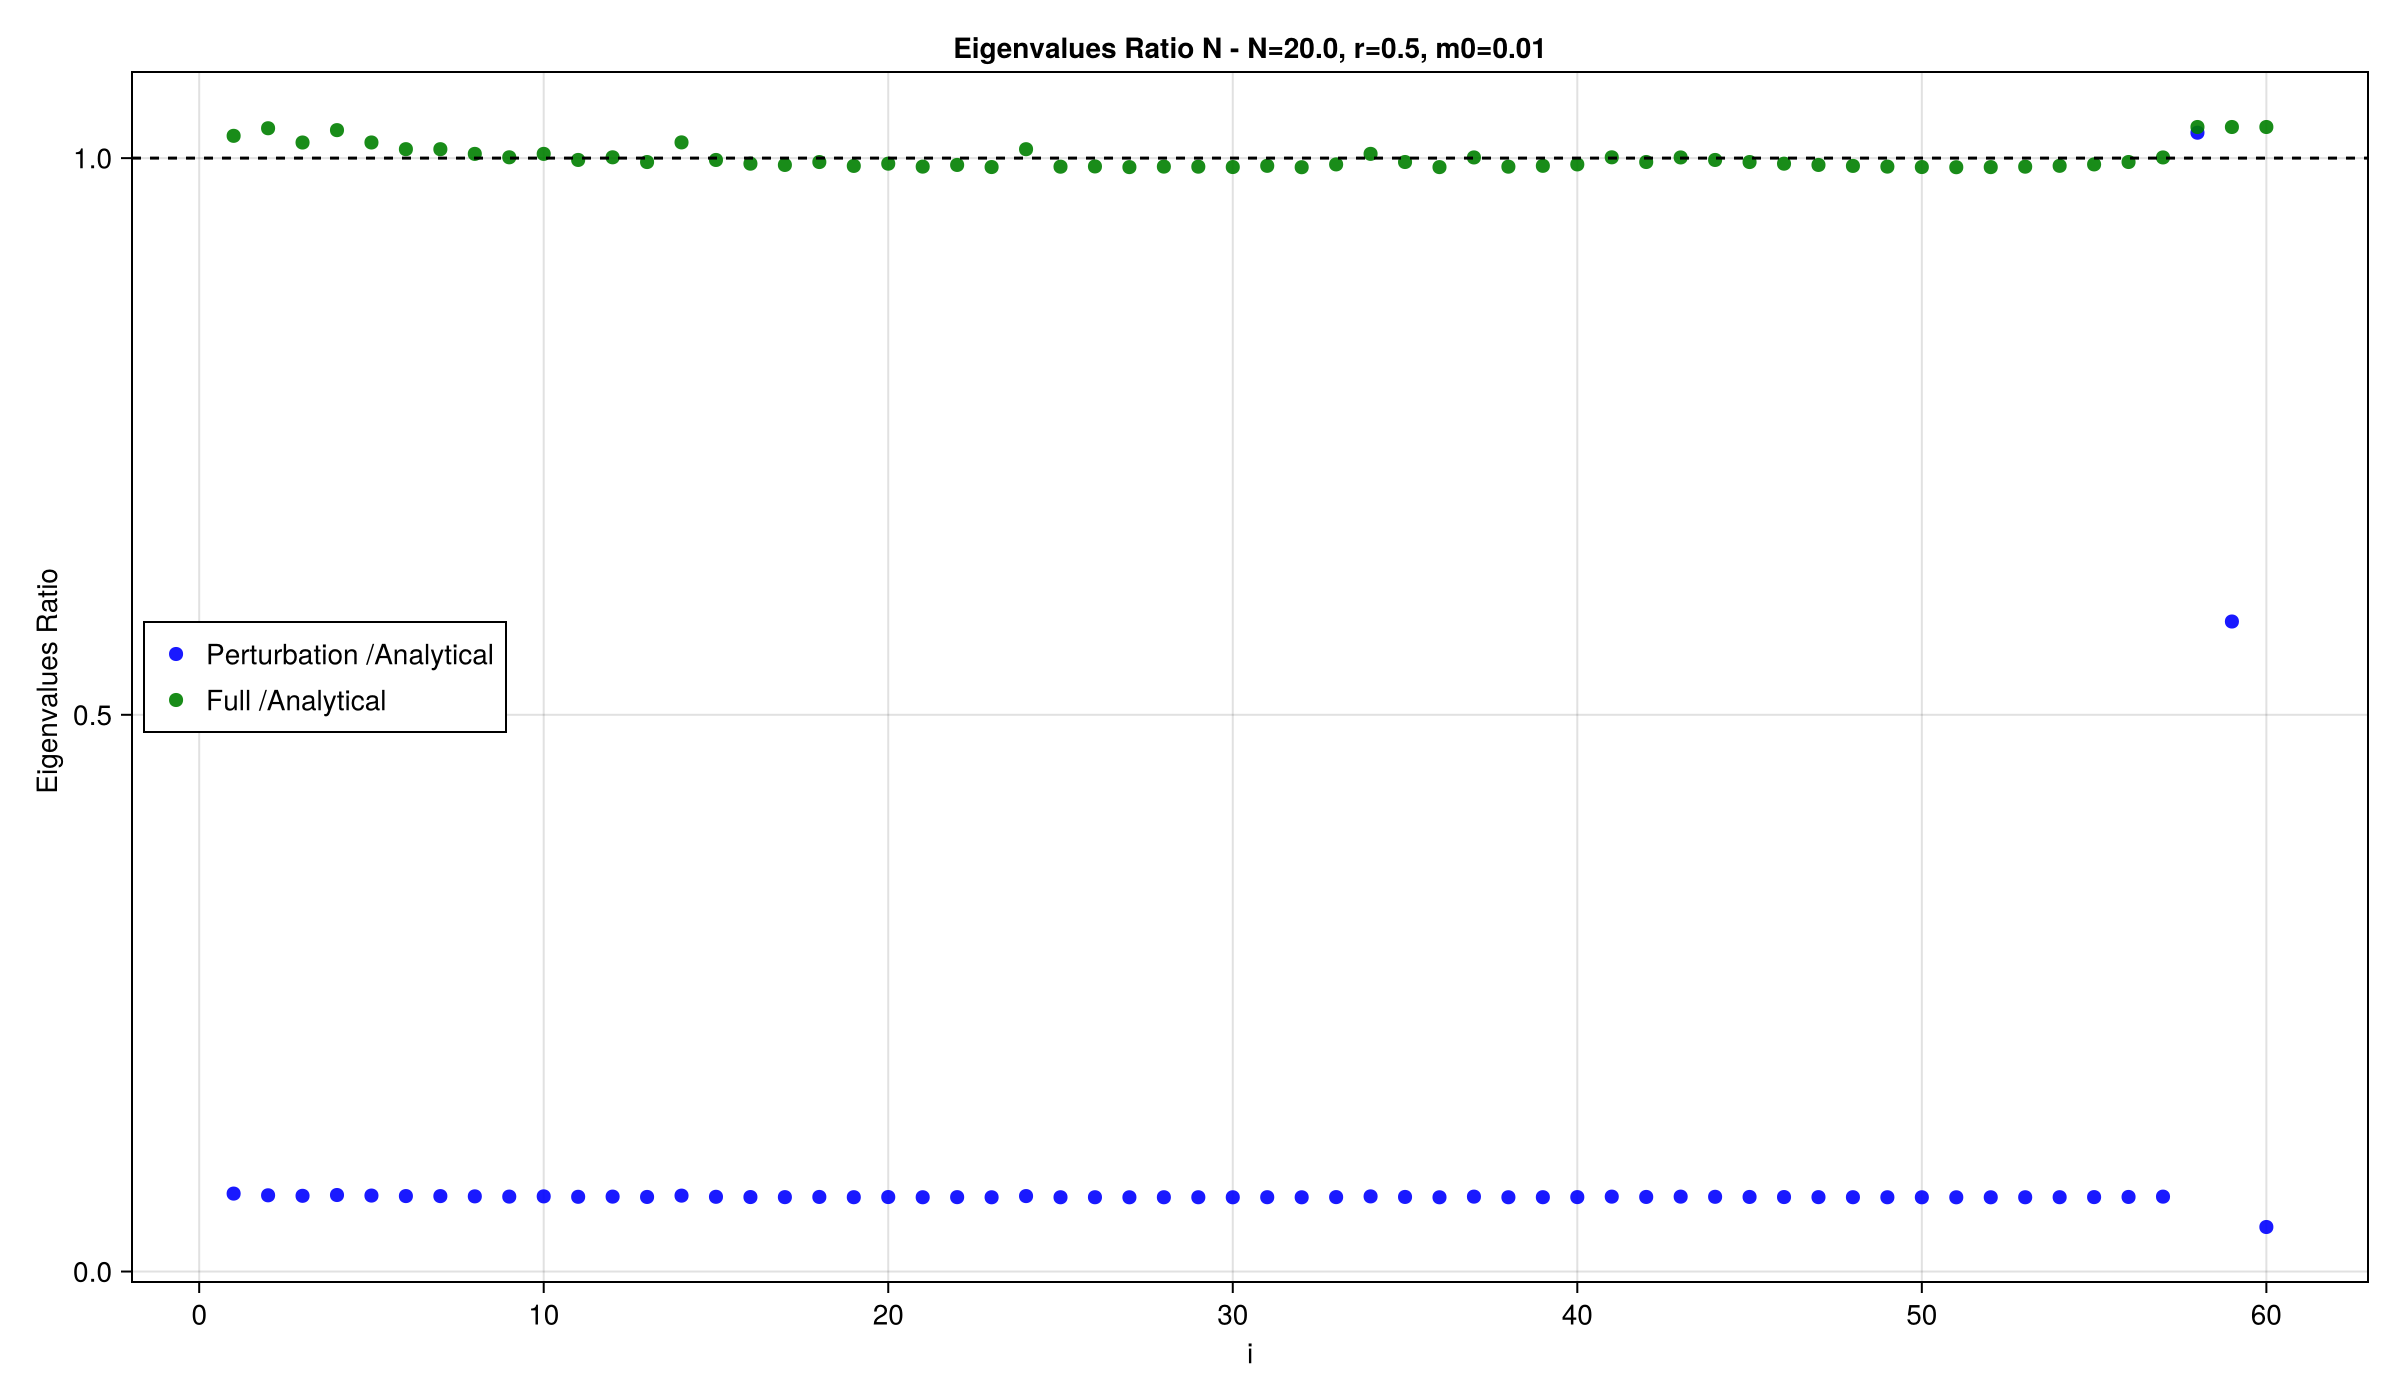

In [93]:

residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((sort(file1) ./ sort(eigen_analytical[1:end])) ))#./ file1) .* 100)
residues_3 = vec(((sort(file2) ./ sort(eigen_analytical[1:end])) ))#./ file2) .* 100)



# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Ratio ",
    title="Eigenvalues Ratio N - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:end], residues_1[1:end], label="Perturbation /Full", markersize=10, alpha=0.9, color=:purple)
scatter!(ax,  indices1[1:end],(residues_3[1:end]), label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end], (residues_2[1:end]), label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash)
#hlines!(ax, 0.0001, color=:black, linestyle=:dash)  

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lc)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/oldeigenvalues_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png", fig)


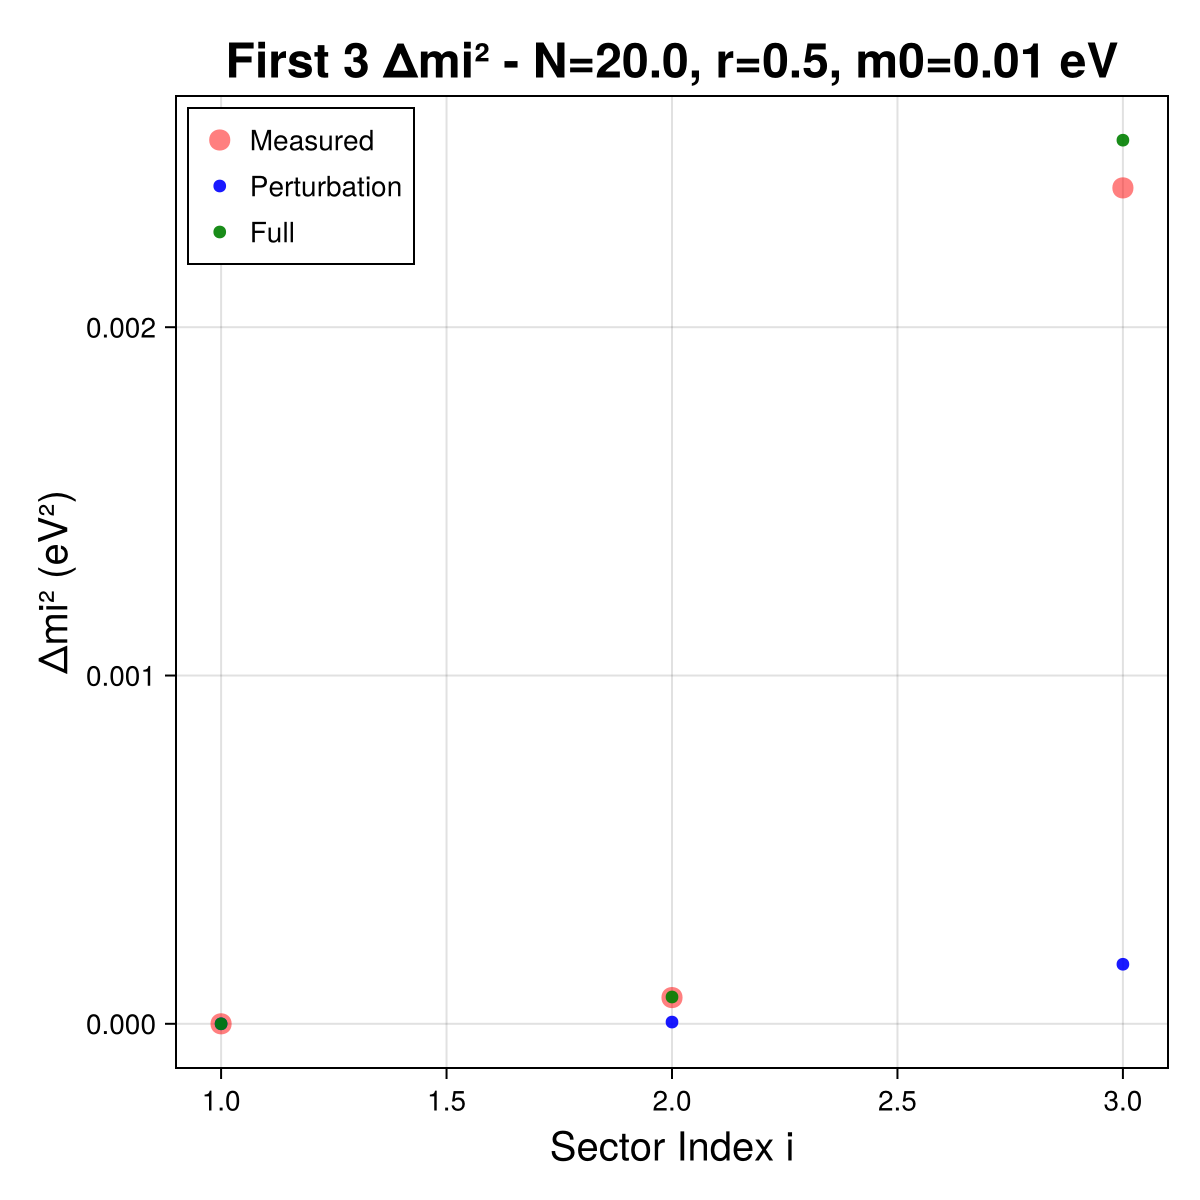

In [94]:
# Read the three txt files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_fullold_NNM_NO_$N $r $m0.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_pertnew_NNM_NO_$N $r $m0.txt"))

file1=(file1[1:end])
file2=(file2[1:end])
# Create indices for x-axis
indices1 = 1:length(file1)
indices2 = 1:length(file2)

# Create the plot
fig = Figure(size=(600, 600))
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Δmi² (eV²)",
    title="First 3 Δmi² - N=$N, r=$r, m0=$m0 eV",
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,)

# Plot scatter points for each file with different colors
scatter!(ax, indices2[1:3], h_analytical[1:3], label="Measured", markersize=15, alpha=0.5, color=:red)
scatter!(ax, indices1[1:3], file2[1:3], label="Perturbation", markersize=9, alpha=0.9, color=:blue)

scatter!(ax, indices2[1:3], file1[1:3], label="Full", markersize=9, alpha=0.9, color=:green)


#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/oldh_3_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


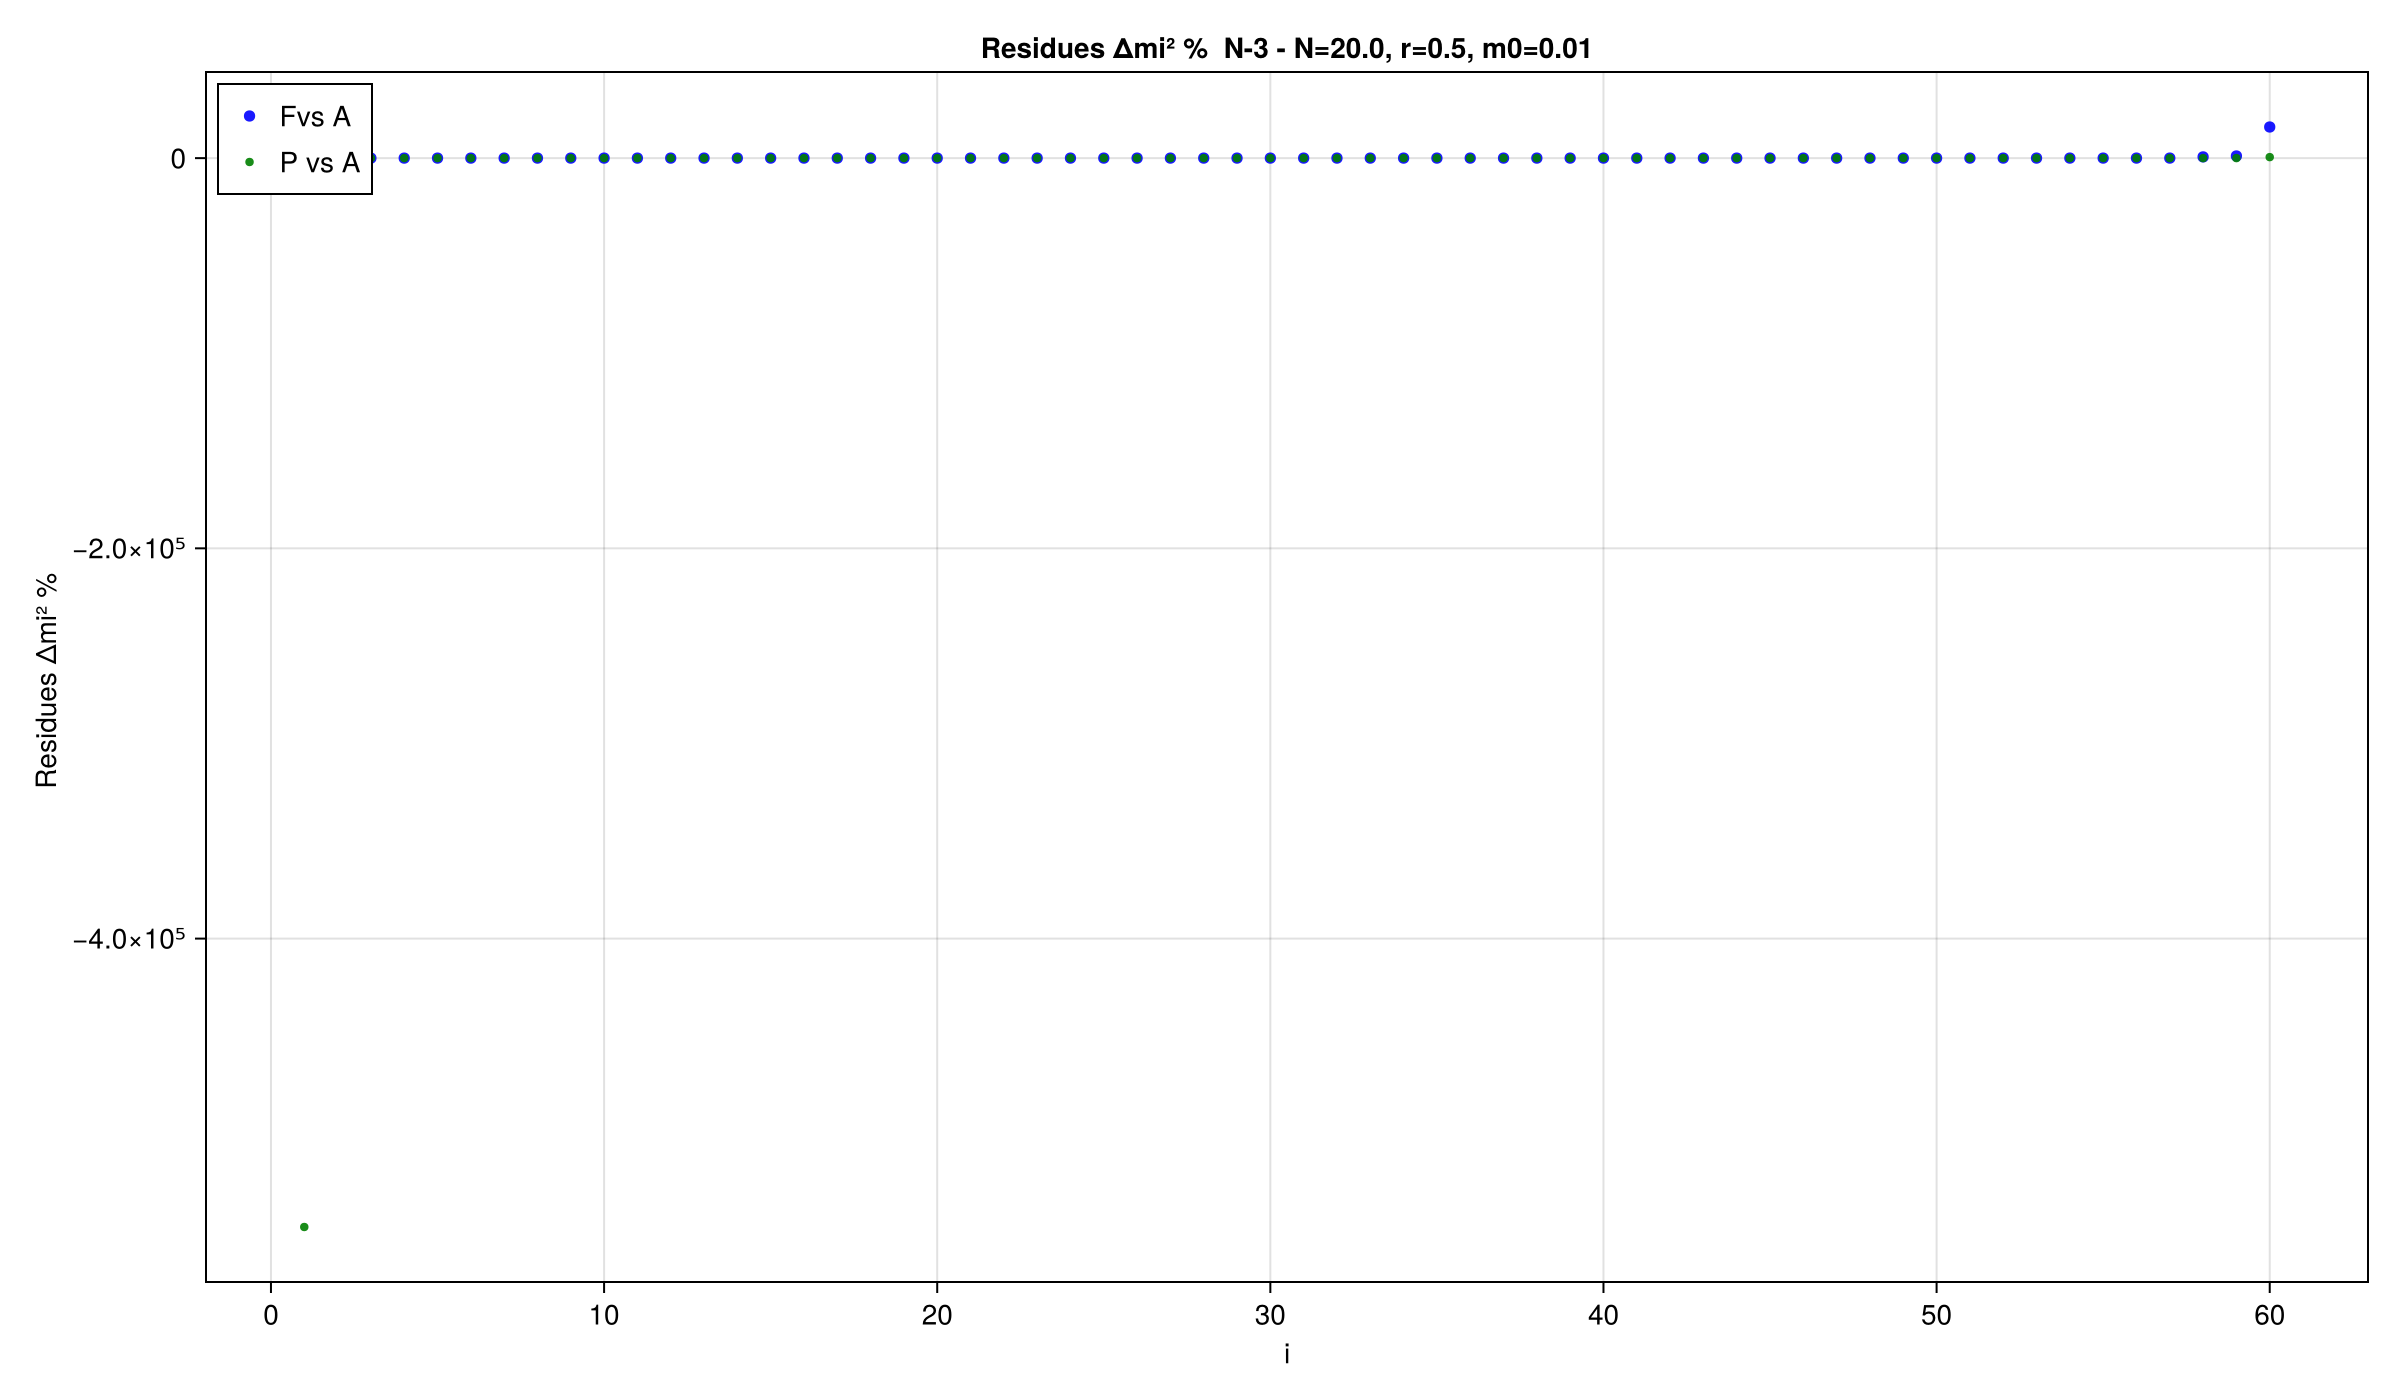

CairoMakie.Screen{IMAGE}


In [95]:

residues_1 = vec(((file1 .- file2) ./ file1) .* 100)
residues_2 = vec(((file1 .- (h_analytical[1:end])) ))#./ file1) .* 100)
residues_3 = vec(((file2 .- (h_analytical[1:end])) ))#./ file2) .* 100)


# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Residues Δmi² % ",
    title="Residues Δmi² %  N-3 - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:3], residues_1[1:3], label="P vs F", markersize=10, alpha=0.7, color=:purple)
scatter!(ax, indices1[1:end], sort(residues_2[1:end]), label="Fvs A", markersize=8, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end], sort(residues_3[1:end]), label="P vs A", markersize=6, alpha=0.9, color=:green)


#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_res_NND_NO_$N $r $m0.png", fig)
display(fig)


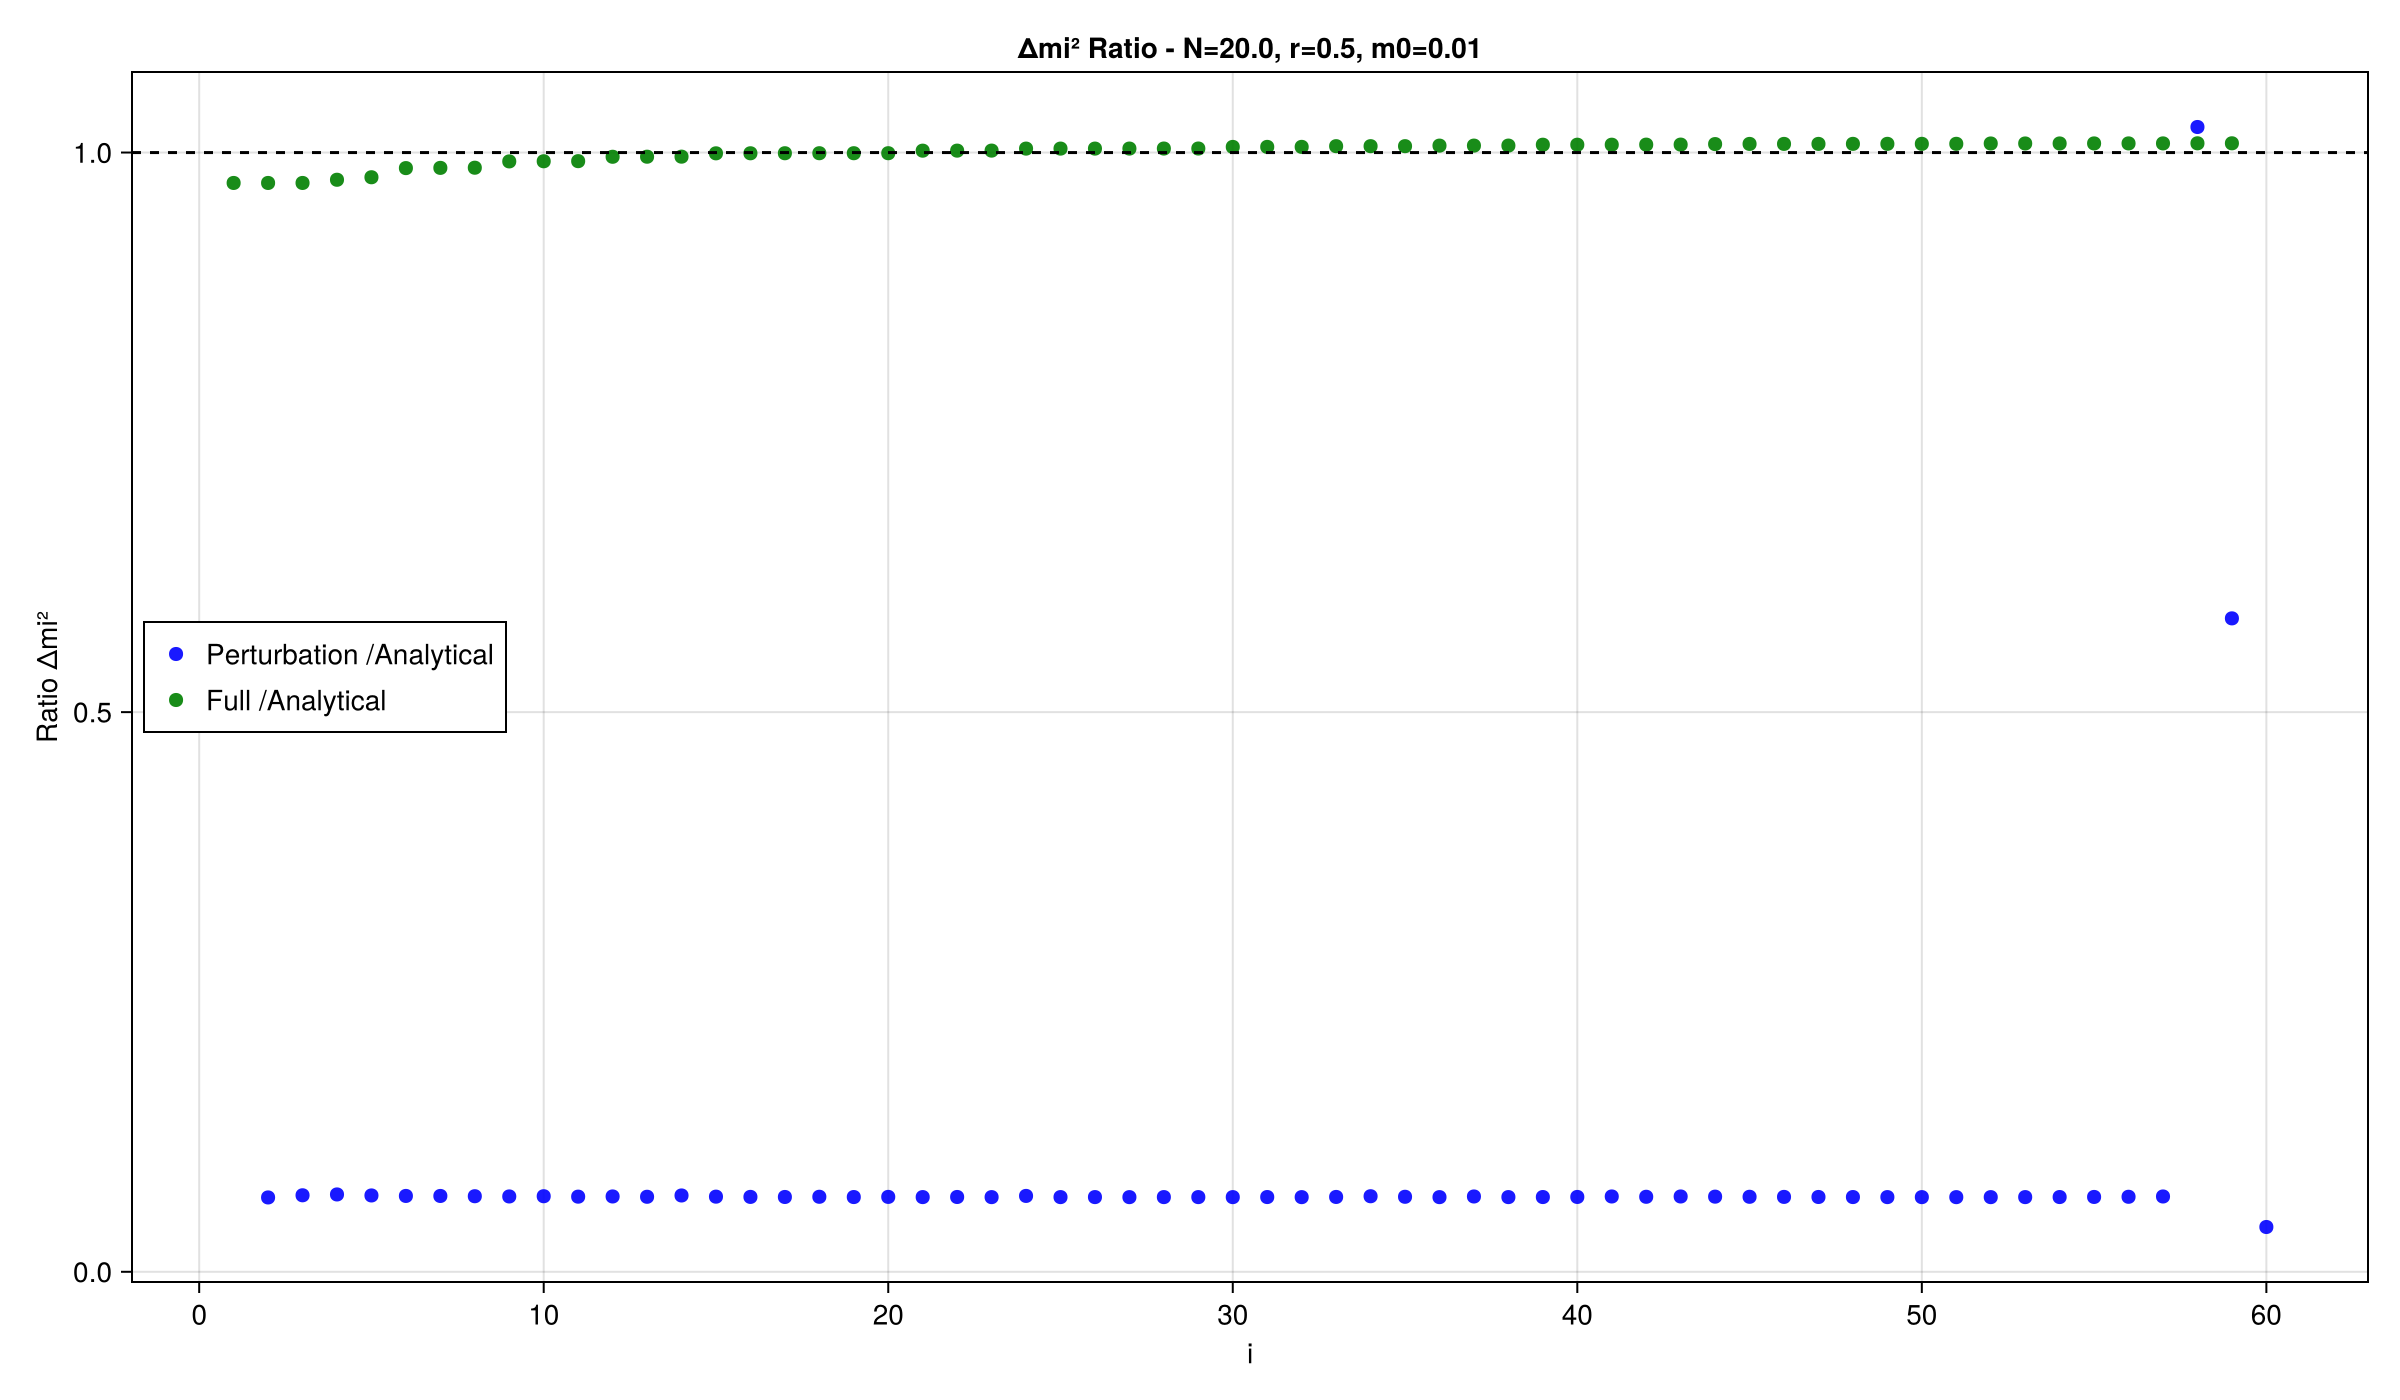

In [96]:



residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((sort(h_analytical[1:end]./sort(file1))) ))#./ file1) .* 100)
residues_3 = vec(((sort(file2) ./ sort(h_analytical[1:end]))) )#./ file2) .* 100)
    
# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Ratio Δmi²",
    title="Δmi² Ratio - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:end-3], residues_1[1:end-3], label="Perturbation /Full", markersize=10, alpha=0.9, color=:purple)
scatter!(ax,  indices1[1:end], residues_3[1:end], label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end], residues_2[1:end], label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash)
#hlines!(ax, 1e-8, color=:black, linestyle=:dash)
#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lc)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/oldh_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png", fig)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


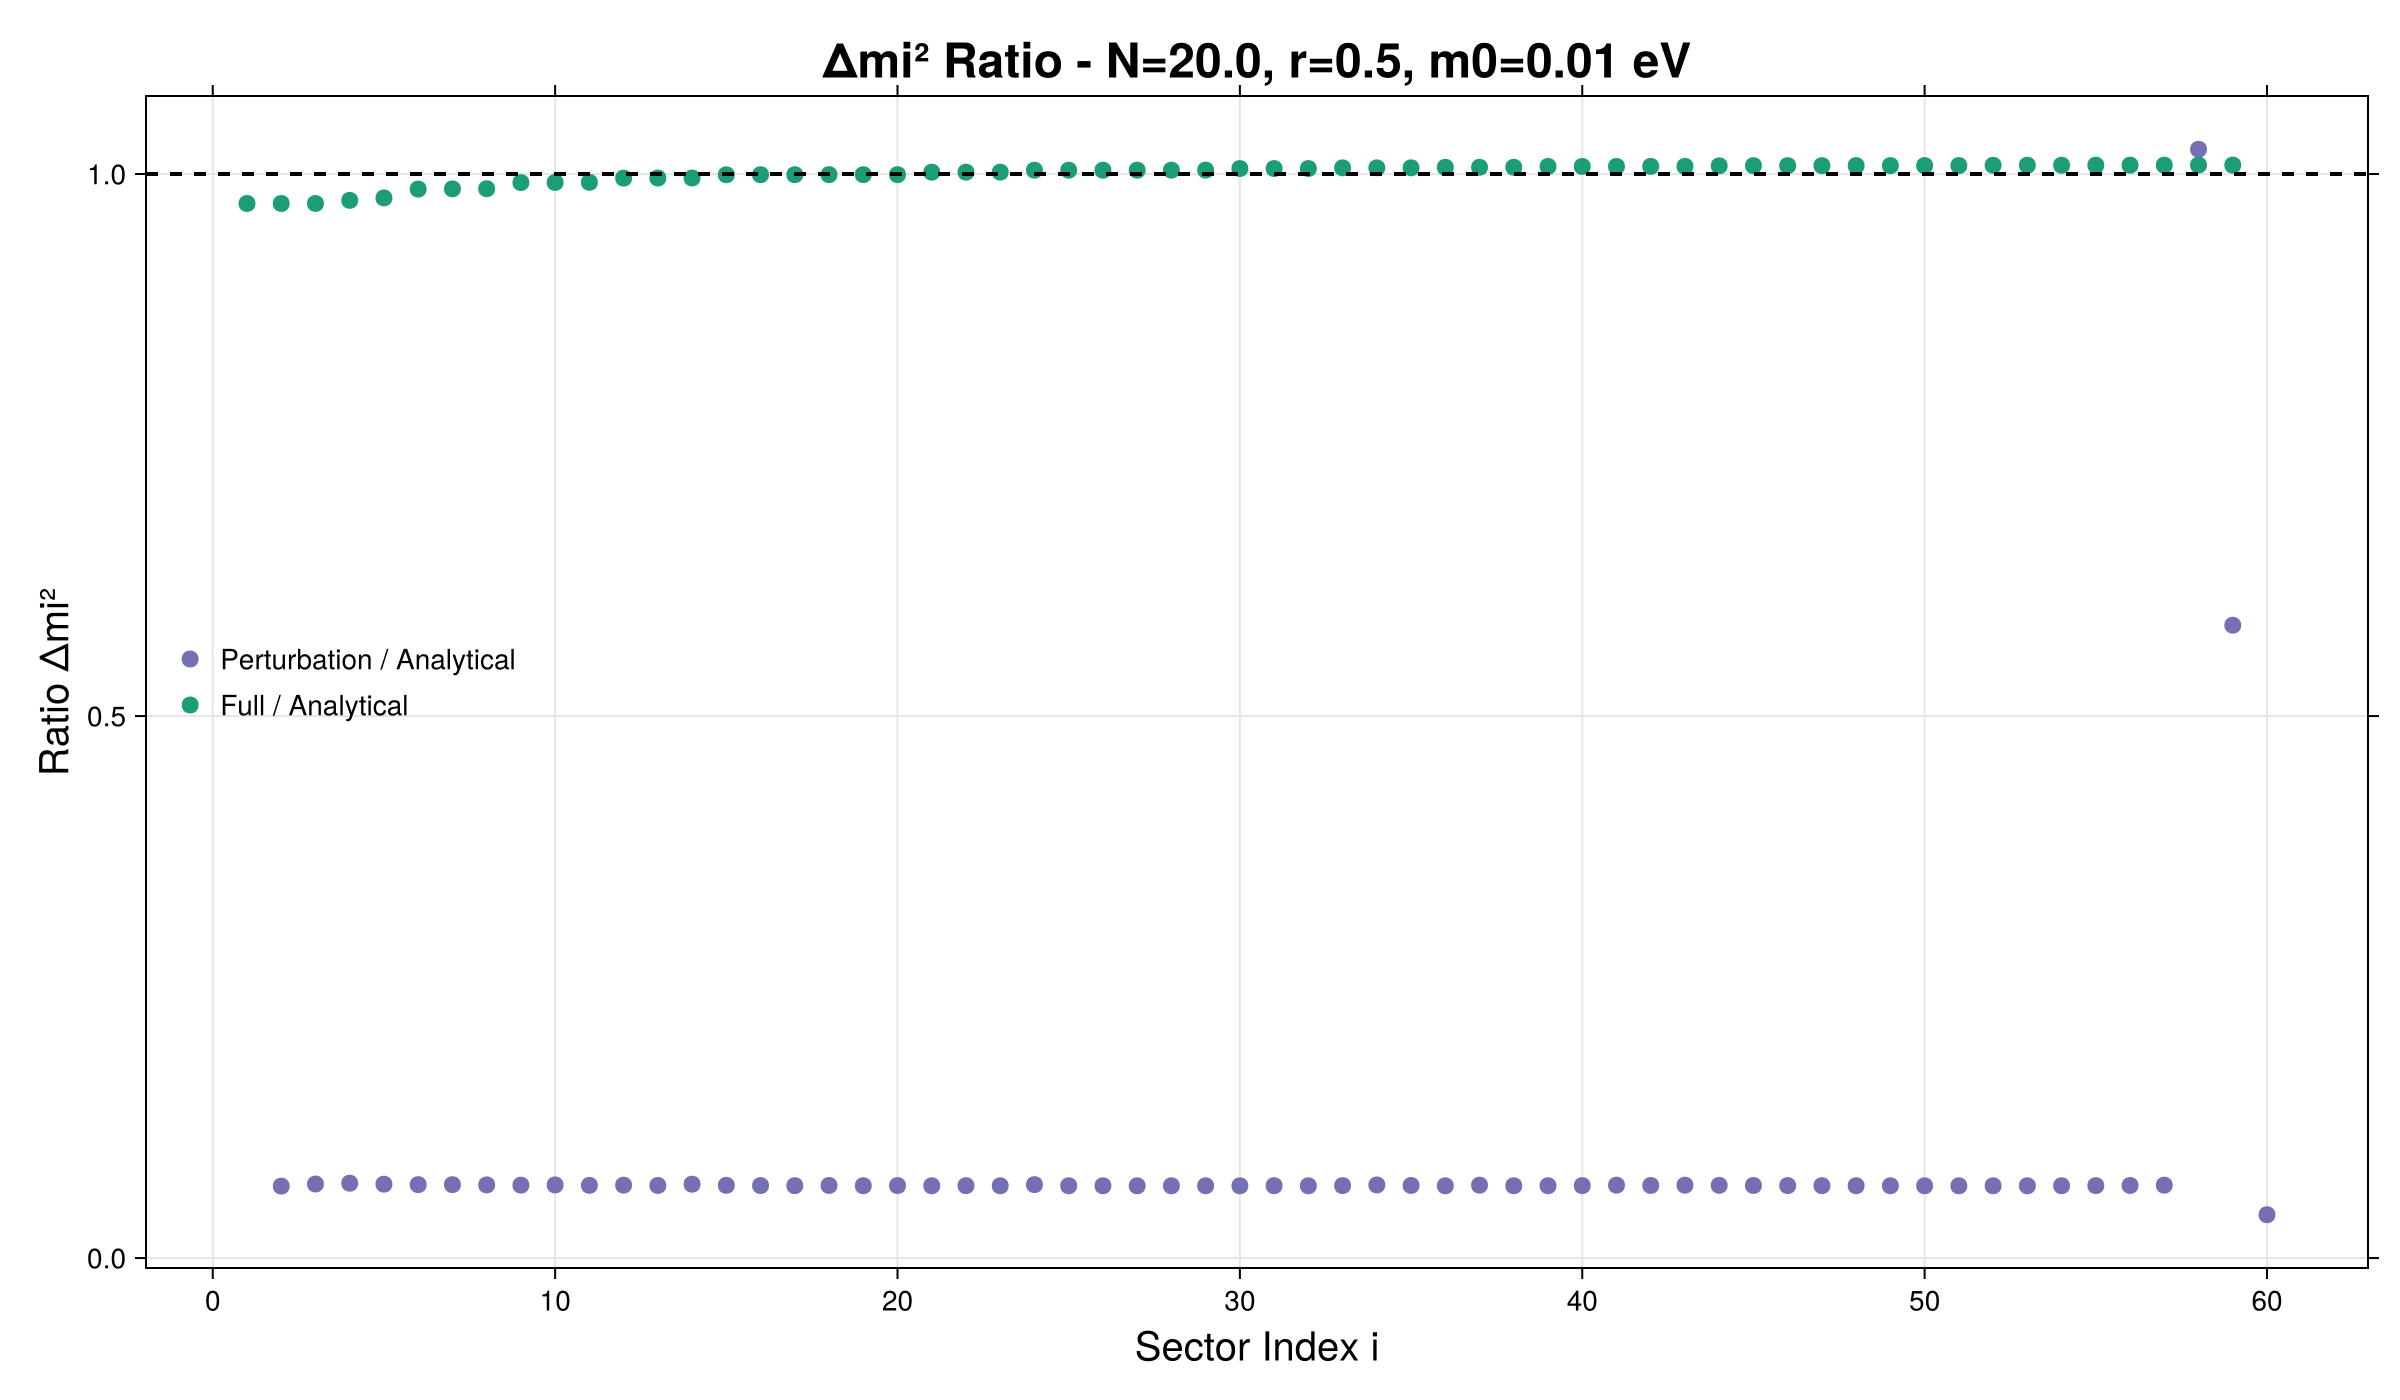

In [99]:
using CairoMakie
using Colors

# Compute residues / ratios
residues_1 = file1 ./ file2
residues_2 = sort(h_analytical ./ sort(file1))
residues_3 = sort(file2) ./ sort(h_analytical)

# Dark2_8 palette
palette = cgrad(:Dark2_8, categorical=true)
color_pert_analytical = palette[3]   # blue
color_full_analytical = palette[1]   # green

# Title as plain string (safe)
title_str = "Δmi² Ratio - N=$N, r=$r, m0=$m0 eV"

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Ratio Δmi²",
    title= title_str    
    ,   # plain string with LaTeX
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Scatter plots
scatter!(ax, indices1[1:end], residues_3[1:end],
    label="Perturbation / Analytical",
    color=color_pert_analytical,
    markersize=12
)

scatter!(ax, indices2[1:end], residues_2[1:end],
    label="Full / Analytical",
    color=color_full_analytical,
    markersize=12
)

# Optional: perturbation / full
# scatter!(ax, indices1[1:end-3], residues_1[1:end-3],
#     label="Perturbation / Full",
#     color=palette[3],
#     markersize=8
# )

# Horizontal reference line at 1
hlines!(ax, 1, color=:black, linestyle=:dash, linewidth=2)

# Legend
axislegend(ax, position=:lc, framevisible=false, fontsize=14)

# Display or save
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/oldh_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png", fig)


DELTAM^2 dependency on r

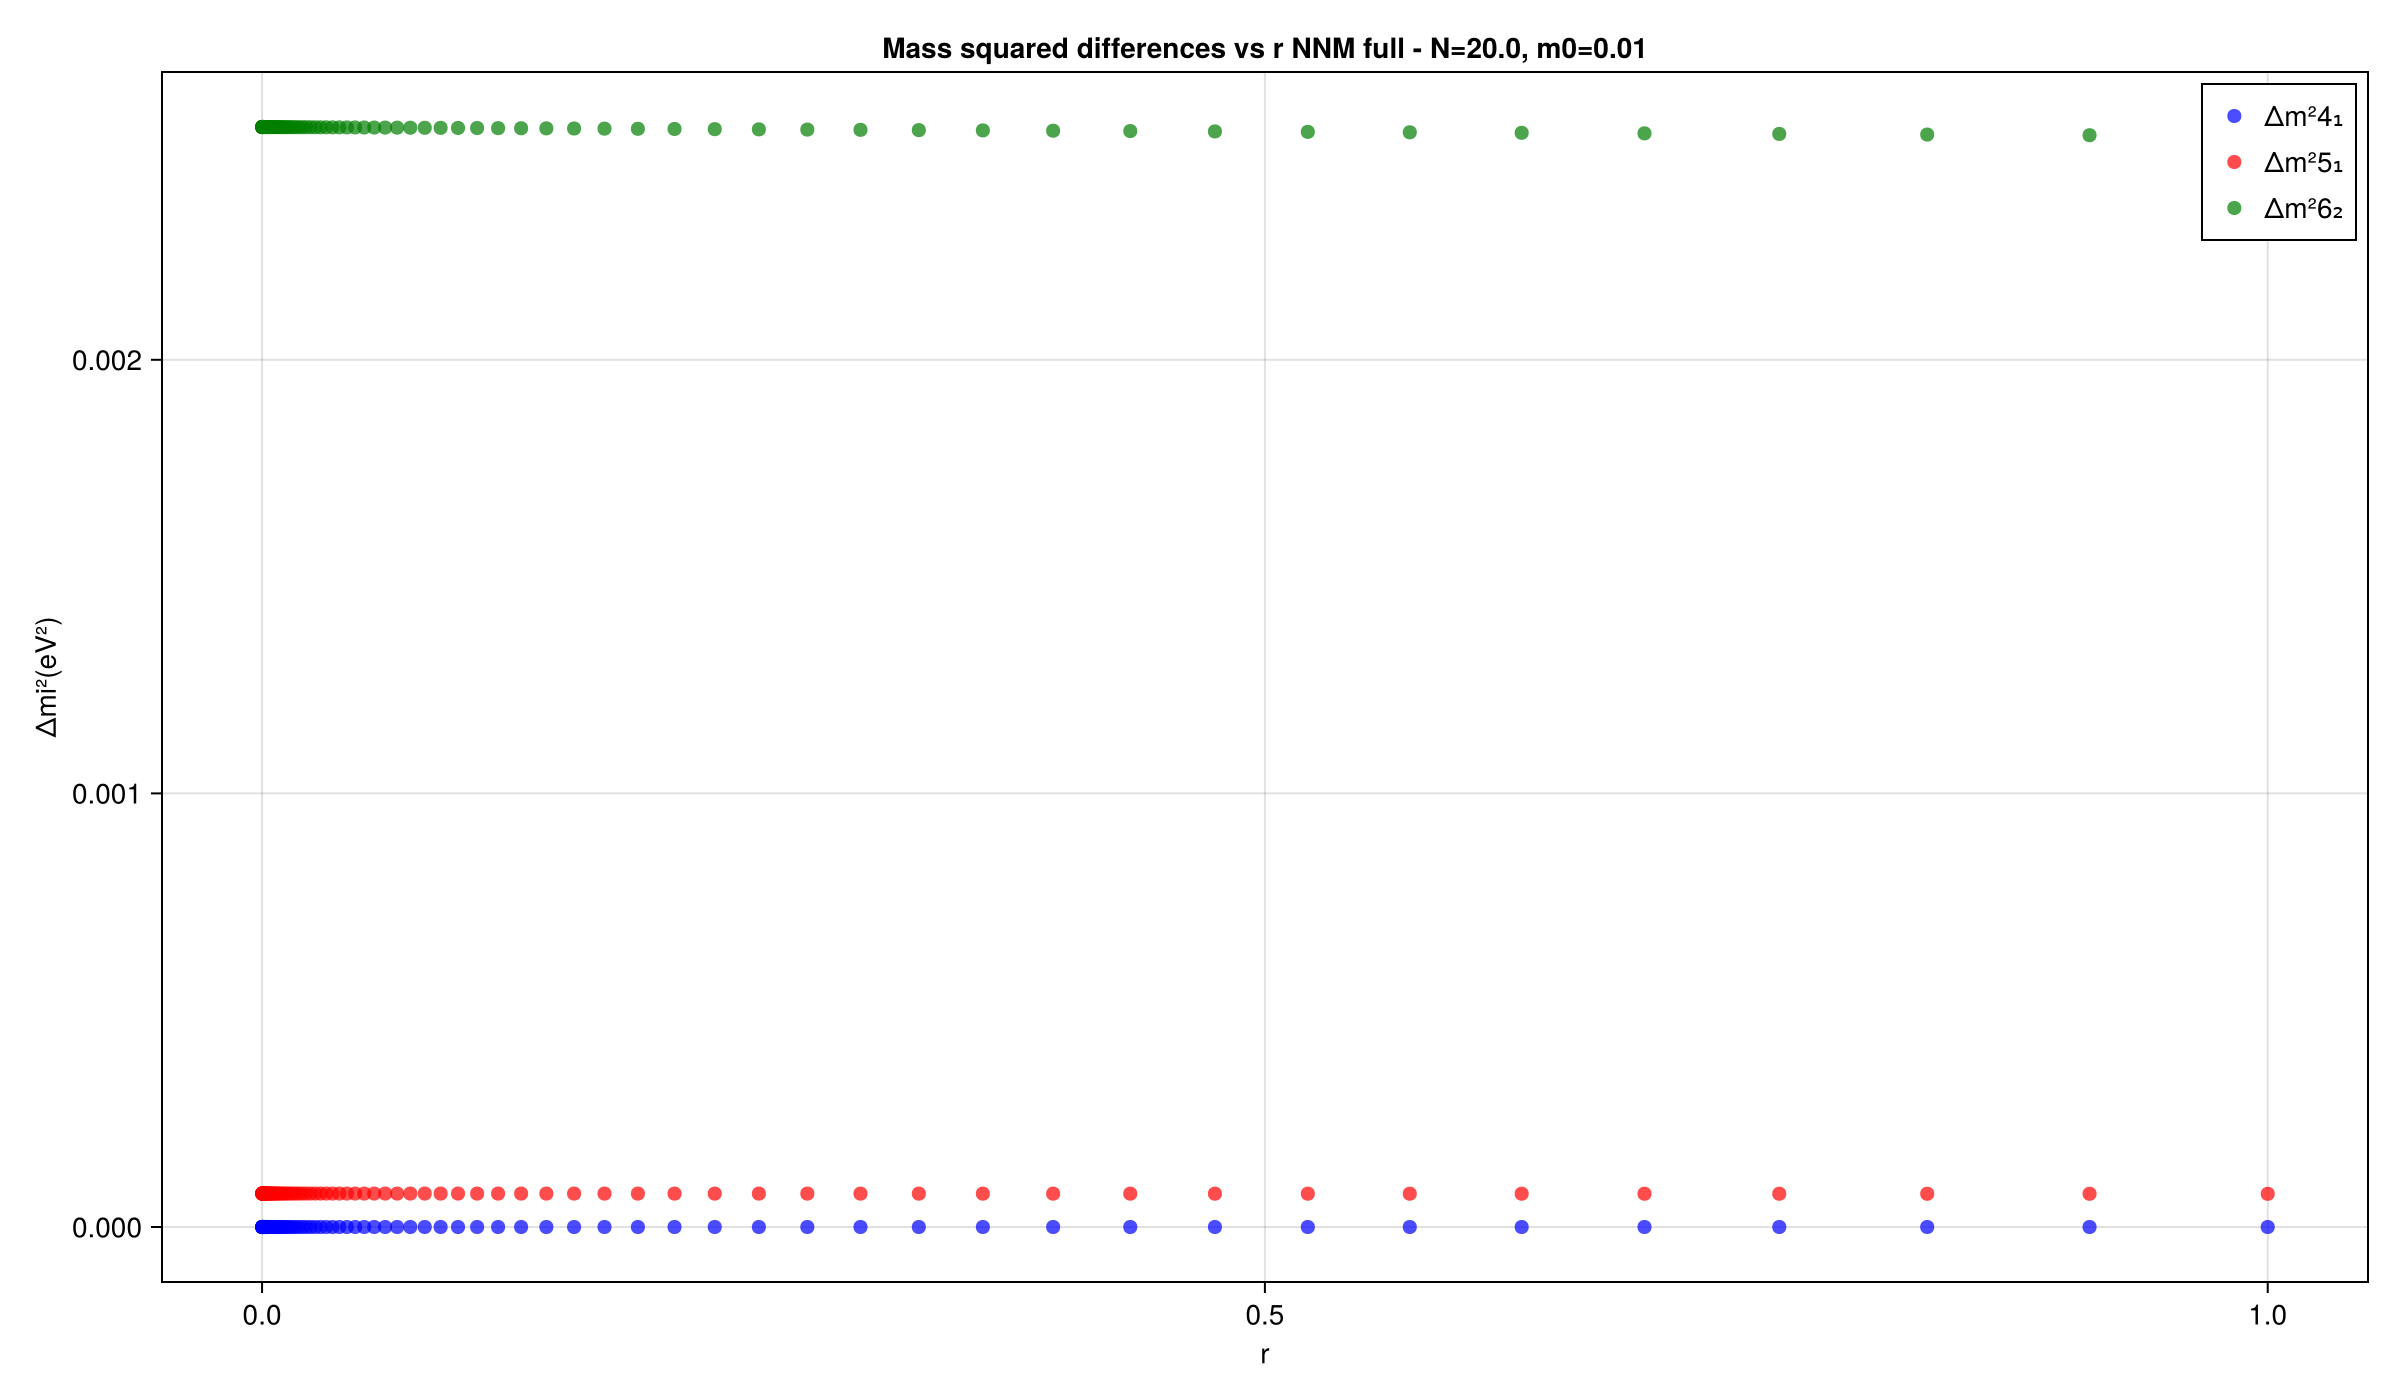

In [98]:
using CairoMakie
r_range=logrange(1e-4,1,100) #LinRange(0.01,1,20)#

h1=[]
h2=[]
h3=[]
N=par.N
m0=par.m₀

for r in r_range

    p= merge(par, (r =r,))
    

    f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    FinalUmatrix, h, eigenvalues = f1(p)
    push!(h1, h[1])
    push!(h2, h[2])
    push!(h3, h[3])
    
end

fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="r",
    ylabel="Δmi²(eV²)",
    title="Mass squared differences vs r NNM full - N=$N, m0=$m0")   
scatter!(ax, r_range, h1, label="Δm²4₁", markersize=10, alpha=0.7, color=:blue)
scatter!(ax, r_range, h2, label="Δm²5₁", markersize=10, alpha=0.7, color=:red)
scatter!(ax, r_range, h3, label="Δm²6₂", markersize=10, alpha=0.7, color=:green)    
# Add legend
axislegend(ax, position=:rt)    
# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_vs_r_NNM_NO_full_$N $m0.png", fig)
display("image/png",fig)